## 
    Alaska
## 
    Time period	: 1940 - 2023
    family :  Weibull
    
    scale	    s(glost,k=5)
    shape       1



In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
import cmaps
from xhistogram.xarray import histogram
from statsmodels.nonparametric.smoothers_lowess import lowess as  sm_lowess
from copy import copy
from matplotlib import cm

In [2]:
import rpy2
from rpy2.robjects.packages import importr, data
from rpy2.robjects import pandas2ri
import rpy2.robjects as ro
from rpy2.robjects import globalenv

extRemes = importr("extRemes")
evgam = importr("evgam")
%load_ext rpy2.ipython

In [3]:
%config InlineBackend.figure_format = 'retina'
plt.style.use("cma.mplstyle")

In [4]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

# READ Return_Level files CONUS

In [5]:
yearb=1941
yeare=2023
itest='Weibull_NOS_sc'
domain='Alaska'

lon_min=185;lon_max=235
lat_min=53;lat_max=75

#### Read output from analysis computed by CONUS_ij_NOS_{itest}_{yearb}-{yeare}.ipynb
file=f'../AFI/{domain}_afi_return.evgam.{yearb}_{yeare}_{itest}.nc'
ds=xr.open_mfdataset(file)
Rlocation   = ds['location']
Rscale      = ds['scale']
Rshape      = ds['shape']
Rrl100      = ds['rl100']
scalepvalue = ds['scalepvalue']
shapepvalue = ds['shapepvalue']
NSscapvalue = ds['NSscalepvalue']
ann_glost = ds['glost']

#### Read AFI data read by CONUS_ij_NOS_{itest}_{yearb}-{yeare}.ipynb
#### Needed for point analysis
files=[f'../AFI/AFIT/AFI_ERA5_{iyear}.nc' for iyear in range(yearb,yeare+1)]

dsa=xr.open_mfdataset(files)
dsa=dsa.sortby('lat')
dsa=dsa.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))
dsa['AFI']=dsa['AFI']*5/9.
dsa['time']=np.arange(yearb,yeare+1,1)
dsa = dsa.merge({'glost':ann_glost})

units='degree-days (°C)'
# parameters for smoothness 
%R fmla_gev <- list(AFI  ~ s(glost,k=5) , ~ 1)
spval = -99999
itest=f'{itest}_{yearb}_{yeare}_{domain}'

The 100-year return level is expressed in degree-days (C).

In [6]:
cmap200=copy(cm.turbo)
cmap200.set_under('darkgrey', 1.0)
#
cmapBR=copy(cmaps.ncl_default)
cmapBR.set_under('darkgrey', 1.0)
#
cmapBR_r=copy(cmaps.ncl_default_r)
cmapBR_rng=copy(cmaps.ncl_default_r)
cmapBR_r.set_under('darkgrey', 1.0)
#
proj=ccrs.PlateCarree()

# Plot scale

<>:46: SyntaxWarning: invalid escape sequence '\d'
<>:48: SyntaxWarning: invalid escape sequence '\d'
<>:46: SyntaxWarning: invalid escape sequence '\d'
<>:48: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_56478/1191401592.py:46: SyntaxWarning: invalid escape sequence '\d'
  ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_56478/1191401592.py:48: SyntaxWarning: invalid escape sequence '\d'
  ax.set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax.get_xticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_56478/1191401592.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Purples',len(clevsa)+20)
/var/folders/2z/v

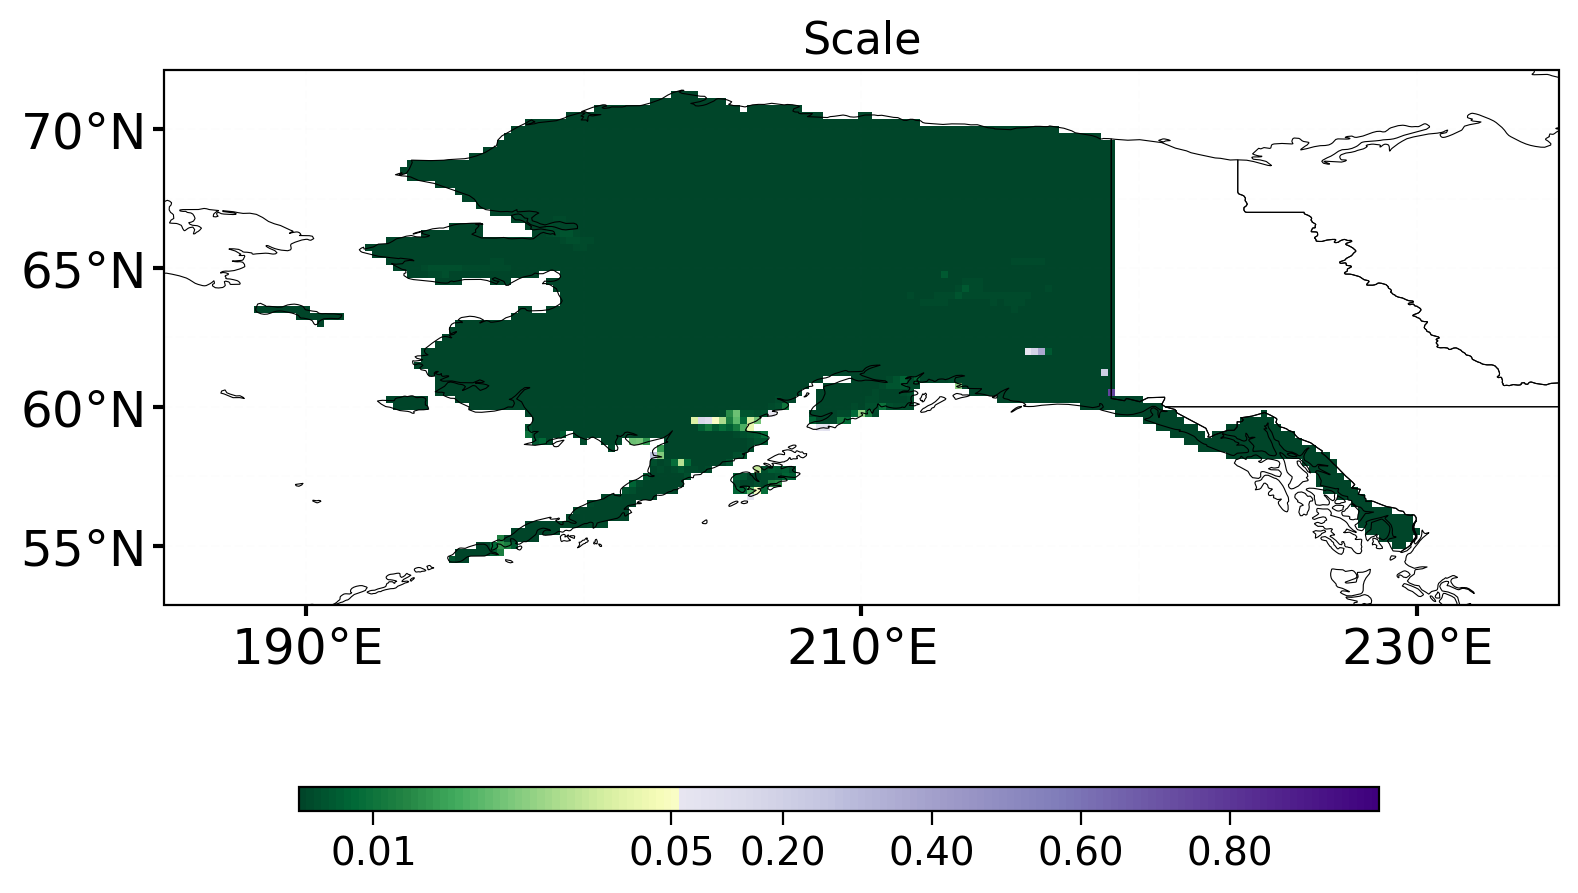

In [7]:
## Build colorbar
clevsa=np.arange(0.06,1.01,0.01)
clevsb=np.arange(0,0.051,0.001)
clevs=np.concatenate((clevsb,clevsa))
cmap = cm.get_cmap('Purples',len(clevsa)+20)
cmaplist = [cmap(i) for i in range(20,cmap.N)]
cmap2 = cm.get_cmap('YlGn_r', len(clevsb)+5)
cmaplist2 = [cmap2(i) for i in range(0,cmap2.N-5)]

my_cmap = colors.LinearSegmentedColormap.from_list('Custom cmap',\
                cmaplist2+cmaplist, len(cmaplist2)+len(cmaplist))

my_cmap.set_under('darkgrey', 1.0)

##########
##########

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(9,6),subplot_kw={'projection':proj})

shrink=0.55
#
#  Location
#

my_cmap.set_under('darkgrey', 1.0)

cc=NSscapvalue.plot(ax=ax,cmap=my_cmap,levels=clevs,add_colorbar=False)
ax.set_title('Scale',fontsize=16)

ax_cbar = fig.add_axes([0.2, 0.1, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar, ticks=[0.01,0.05,0.2,0.4,0.6,0.8],shrink=0.8,location='bottom',orientation='horizontal')
cbar.set_label(label=f'',fontsize=14)
cbar.ax.minorticks_off()
cbar.ax.tick_params(labelsize=14)
####
####
grd = ax.gridlines(
  draw_labels=False, 
  color='gray', alpha=0.01, linestyle='--')

ax.set_xlabel('')
ax.set_ylabel('')
ax.add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
ax.tick_params(axis='both',direction='out',width=1.5,length=4)
ax.set_yticks(ax.get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=18)
ax.set_xticks(ax.get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
ax.set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax.get_xticks()],size=18)

outfile=f'PLOTS/GEV_glost_pvalue_NS{itest}.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

Map of p-value of the smooth terms for a) scale and b) shape parameters. In grey, not enough AFI values > 0.

# Plot Scale

<>:31: SyntaxWarning: invalid escape sequence '\d'
<>:34: SyntaxWarning: invalid escape sequence '\d'
<>:31: SyntaxWarning: invalid escape sequence '\d'
<>:34: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_56478/1669346124.py:31: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_56478/1669346124.py:34: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)


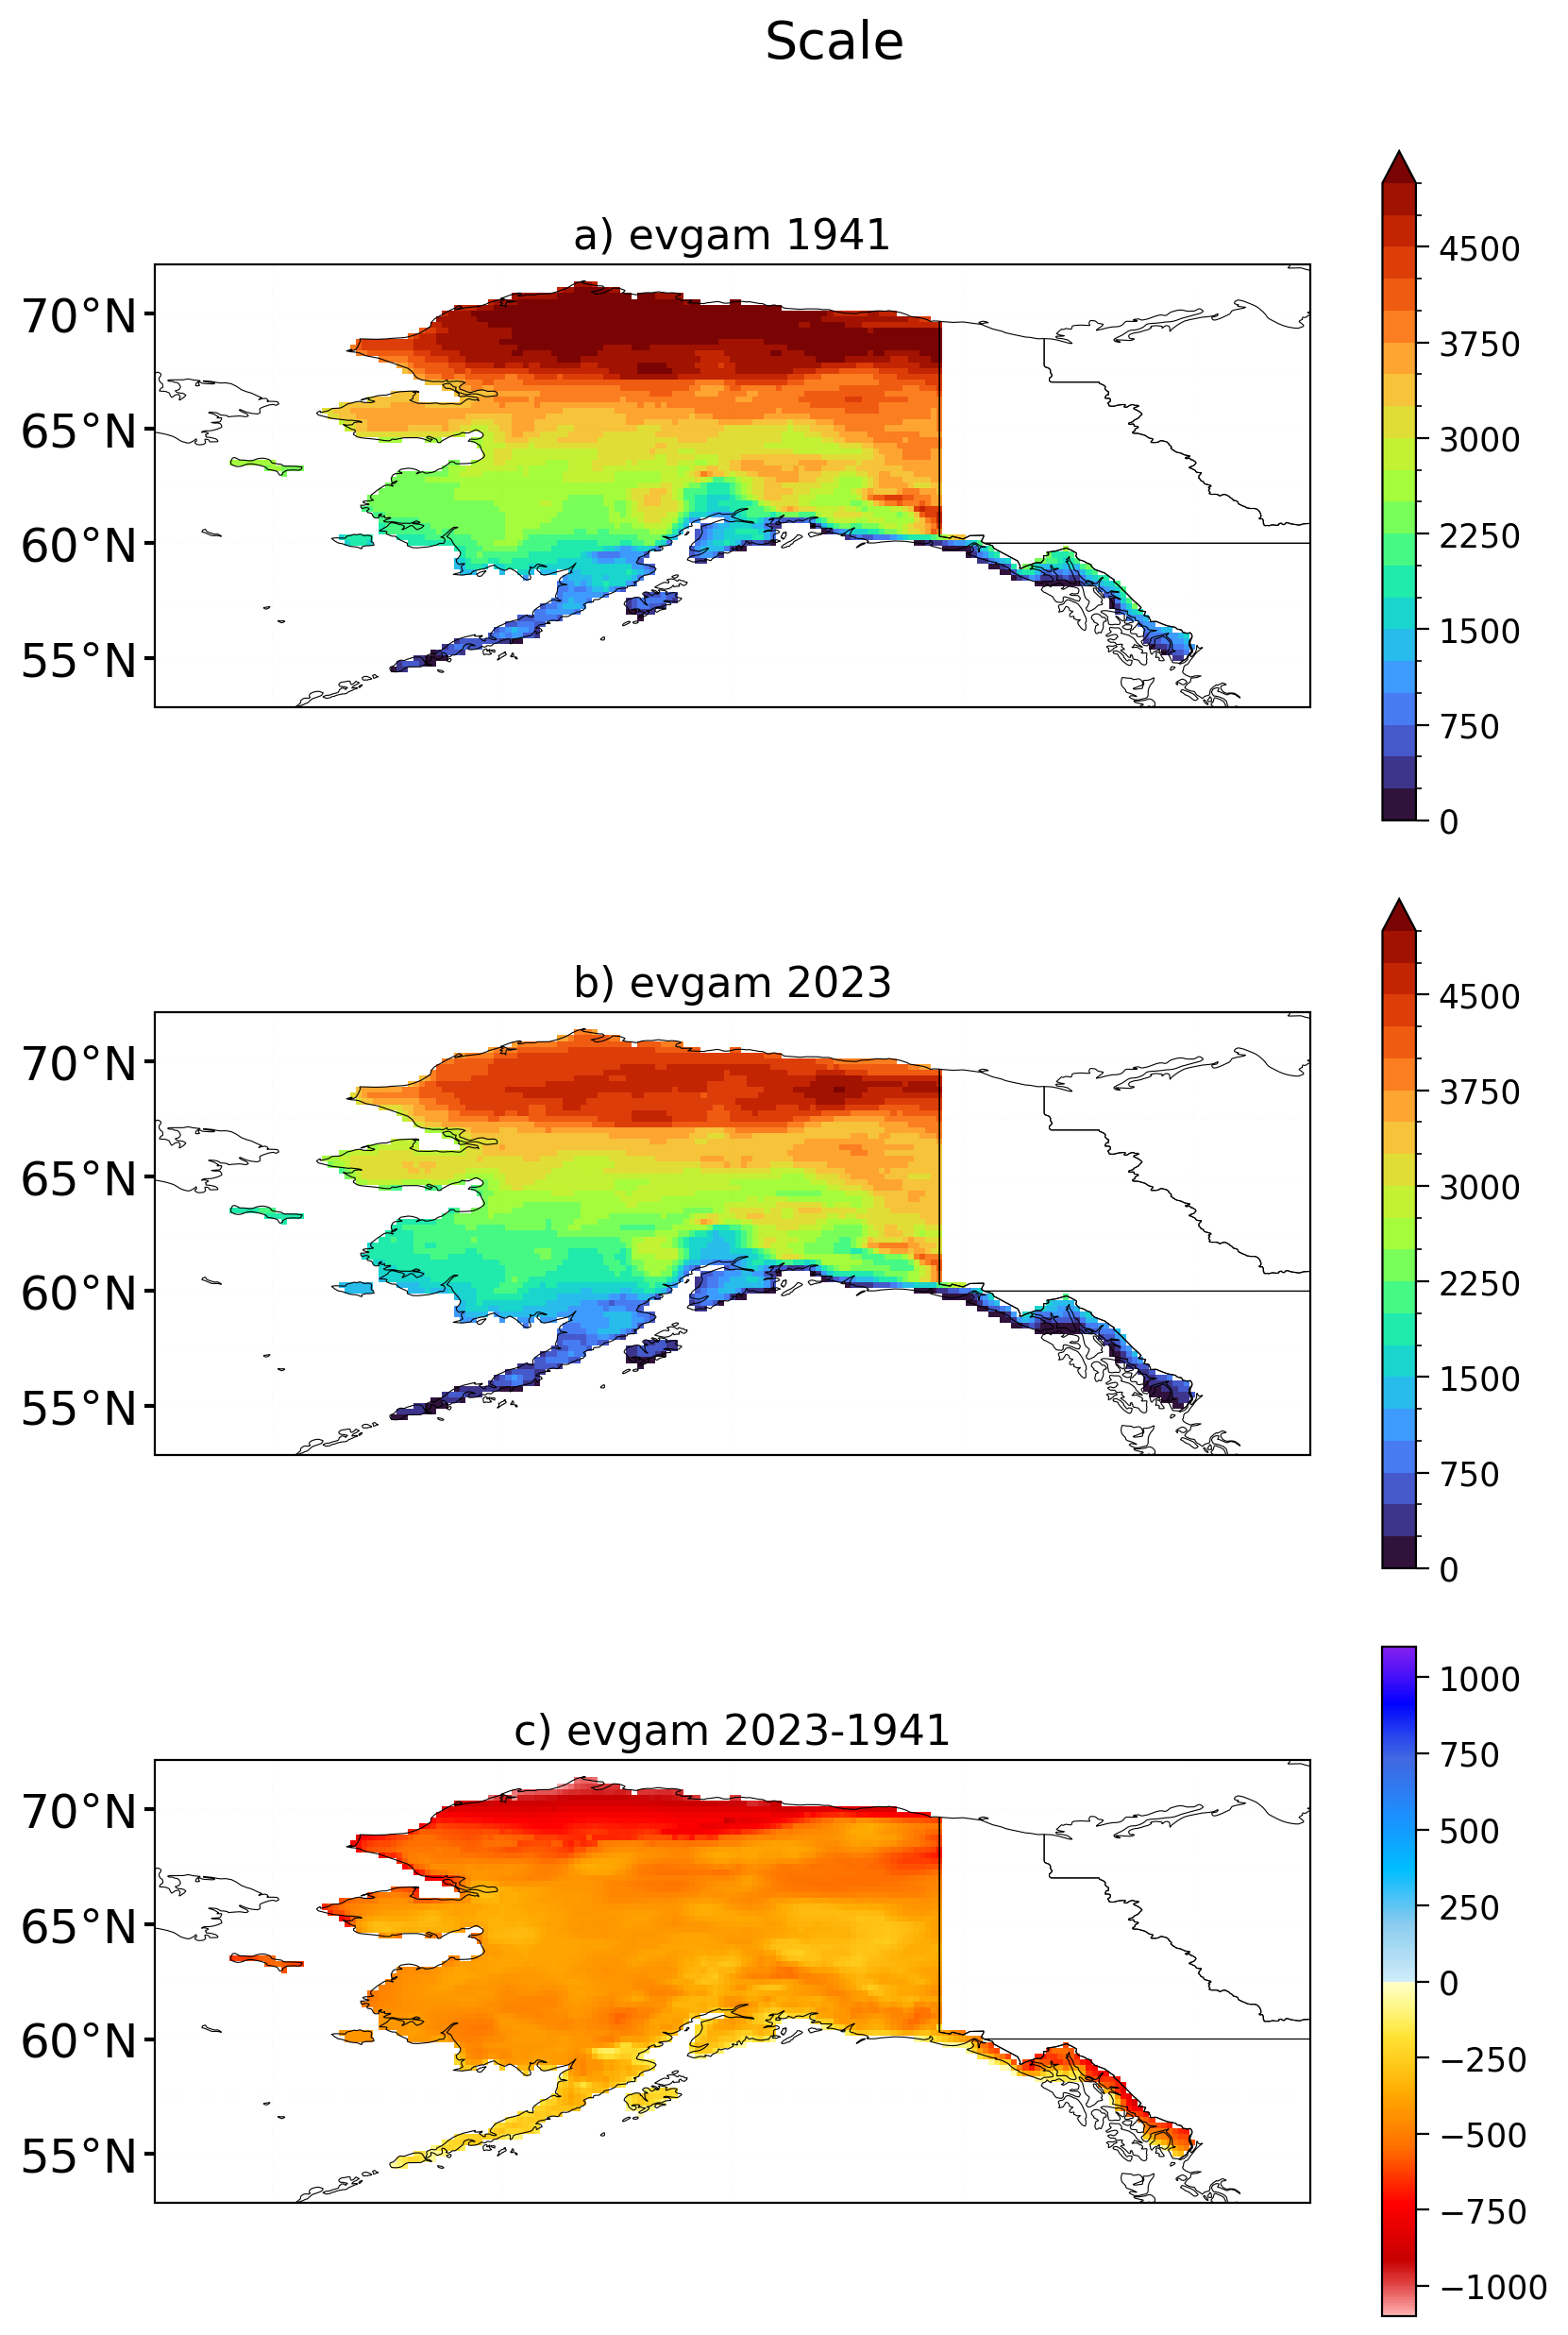

In [14]:
fig, ax = plt.subplots(nrows=3,ncols=1,figsize=(9,13),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.02,top=0.95, left=0.1,right=0.95,hspace=-0.05)
ax=ax.flatten()

shrink=0.85
#
#  Scale
#
clevs = np.arange(0,5250,250)

Rscale.isel(time=0).plot(ax=ax[0],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[0].set_title(f'a) evgam {yearb}',fontsize=16)

Rscale.isel(time=73).plot(ax=ax[1],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[1].set_title(f'b) evgam {yeare}',fontsize=16)

data=Rscale.isel(time=73)-Rscale.isel(time=0)
data=xr.where(Rscale.isel(time=0)==spval,spval,data)
data.plot(ax=ax[2],cmap=cmapBR_r,vmin=-1100,vmax=1100,cbar_kwargs={'label':'','shrink':shrink})
ax[2].set_title(f'c) evgam {yeare}-{yearb}',fontsize=16)
####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == 3: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('')  
fig.suptitle('Scale',fontsize=20)    
outfile=f'PLOTS/GEV_scale_NS{itest}.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

In [18]:
print(f'Map of scale parameters from the GEV analysis performed \n',
f'a) using the R-evgam package for the year {yearb},\n',
f'b) using the R-evgam package for the year {yeare},\n',
f'c) using the R-evgam package difference between the years {yeare} and {yearb}.\n',
f'In grey, not enough AFI values > 0.')

Map of scale parameters from the GEV analysis performed 
 a) using the R-evgam package for the year 1941,
 b) using the R-evgam package for the year 2023,
 c) using the R-evgam package difference between the years 2023 and 1941.
 In grey, not enough AFI values > 0.


# Plot Shape

<>:33: SyntaxWarning: invalid escape sequence '\d'
<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:33: SyntaxWarning: invalid escape sequence '\d'
<>:36: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_56478/3132991527.py:33: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_56478/3132991527.py:36: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)


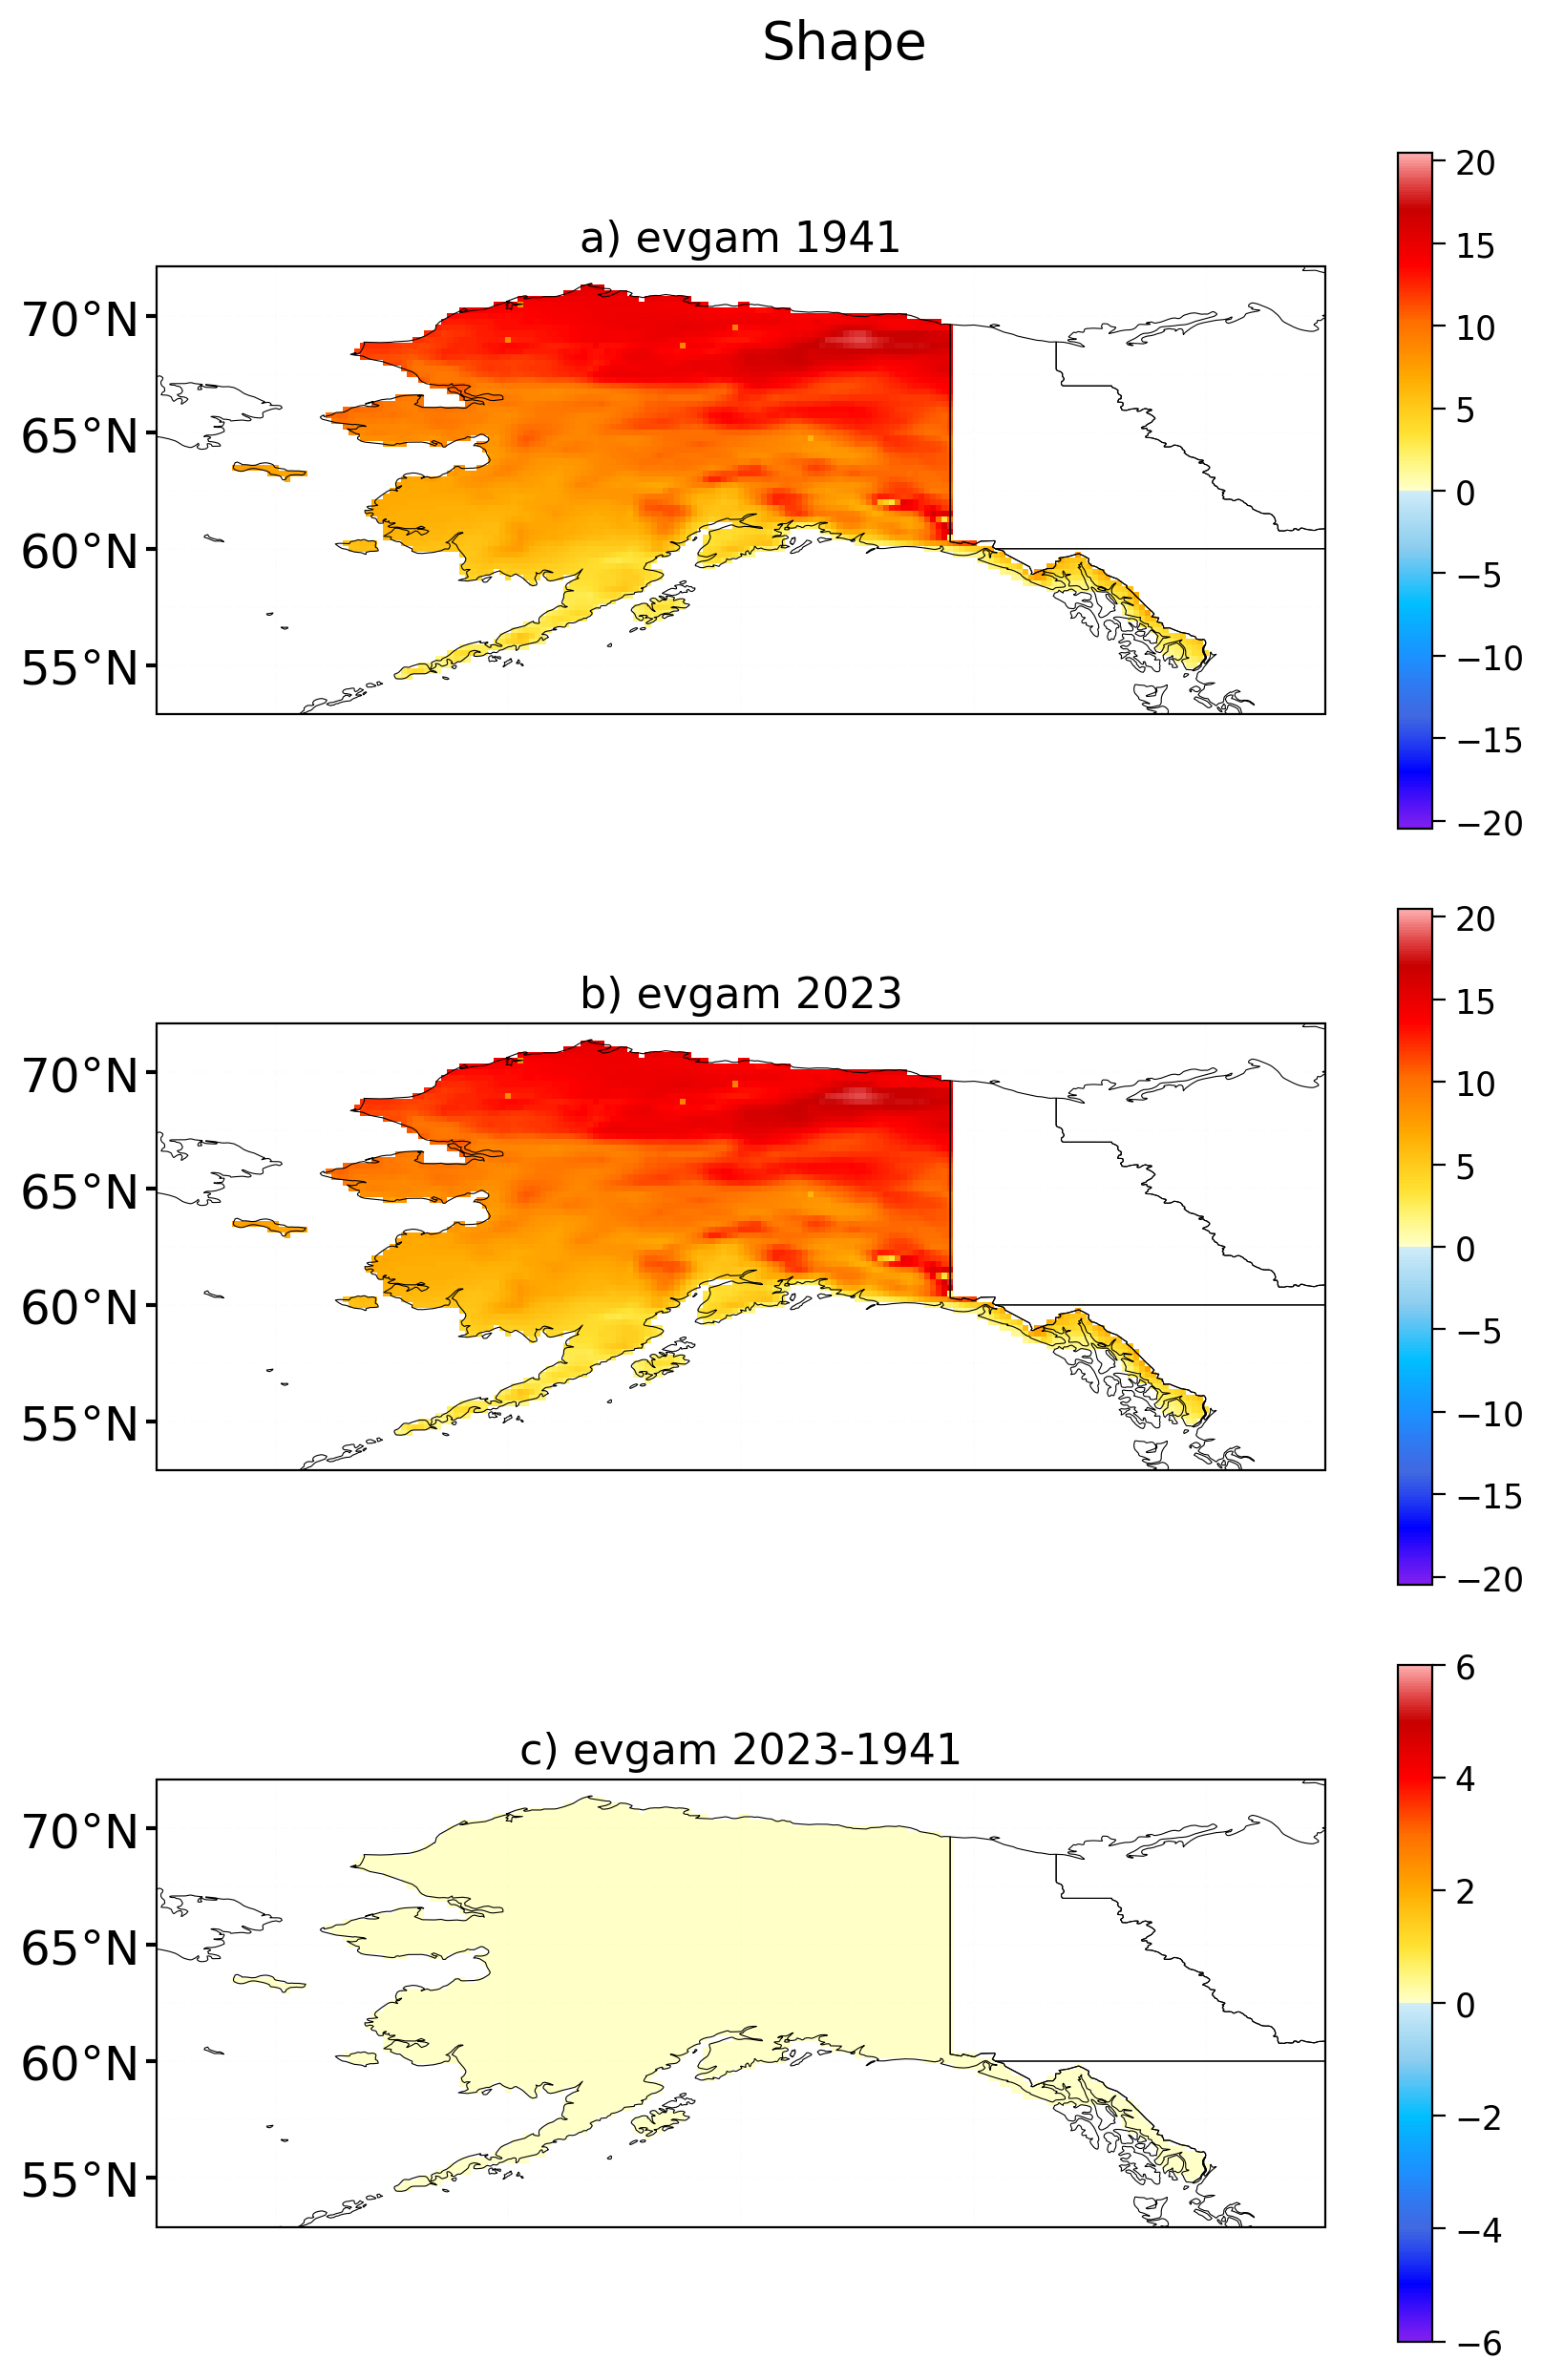

In [18]:
fig, ax = plt.subplots(nrows=3,ncols=1,figsize=(9,13),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.02,top=0.95, left=0.1,right=0.95,hspace=-0.05)
ax=ax.flatten()

shrink=0.85
#
#  Shape
#
clevs = np.arange(-20.5,21.,0.5)

Rshape.isel(time=0).plot(ax=ax[0],cmap=cmapBR,vmin=clevs[0],vmax=-clevs[0],\
 cbar_kwargs={'label':'','shrink':shrink})
ax[0].set_title(f'a) evgam {yearb}',fontsize=16)

Rshape.isel(time=73).plot(ax=ax[1],cmap=cmapBR,vmin=clevs[0],vmax=-clevs[0],\
  cbar_kwargs={'label':'','shrink':shrink})
ax[1].set_title(f'b) evgam {yeare}',fontsize=16)

data=Rshape.isel(time=73)-Rshape.isel(time=0)
data=xr.where(Rshape.isel(time=0)==spval,spval,data)
data.plot(ax=ax[2],cmap=cmapBR,vmin=-6,vmax=6,cbar_kwargs={'label':'','shrink':shrink})
ax[2].set_title(f'c) evgam {yeare}-{yearb}',fontsize=16)
####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == 3: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('')  
fig.suptitle('Shape',fontsize=20)    
outfile=f'PLOTS/GEV_shape_NS{itest}.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

In [30]:
print(f'Map of shape parameters from the GEV analysis performed \n',
f'a) using the R-evgam package for the year {yearb},\n',
f'b) using the R-evgam package for the year {yeare},\n',
f'c) using the R-evgam package difference between the years {yeare} and {yearb}.\n',
f'In grey, not enough AFI values > 0.\n',
f'The black contours are showing the shape parameters contours [-0.5,0.5].')

Map of shape parameters from the GEV analysis performed 
 a) using the R-evgam package for the year 1941,
 b) using the R-evgam package for the year 2023,
 c) using the R-evgam package difference between the years 2023 and 1941.
 In grey, not enough AFI values > 0.
 The black contours are showing the shape parameters contours [-0.5,0.5].


# Plot 100y Return Level 

<>:31: SyntaxWarning: invalid escape sequence '\d'
<>:34: SyntaxWarning: invalid escape sequence '\d'
<>:31: SyntaxWarning: invalid escape sequence '\d'
<>:34: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_56478/2535649496.py:31: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_56478/2535649496.py:34: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)


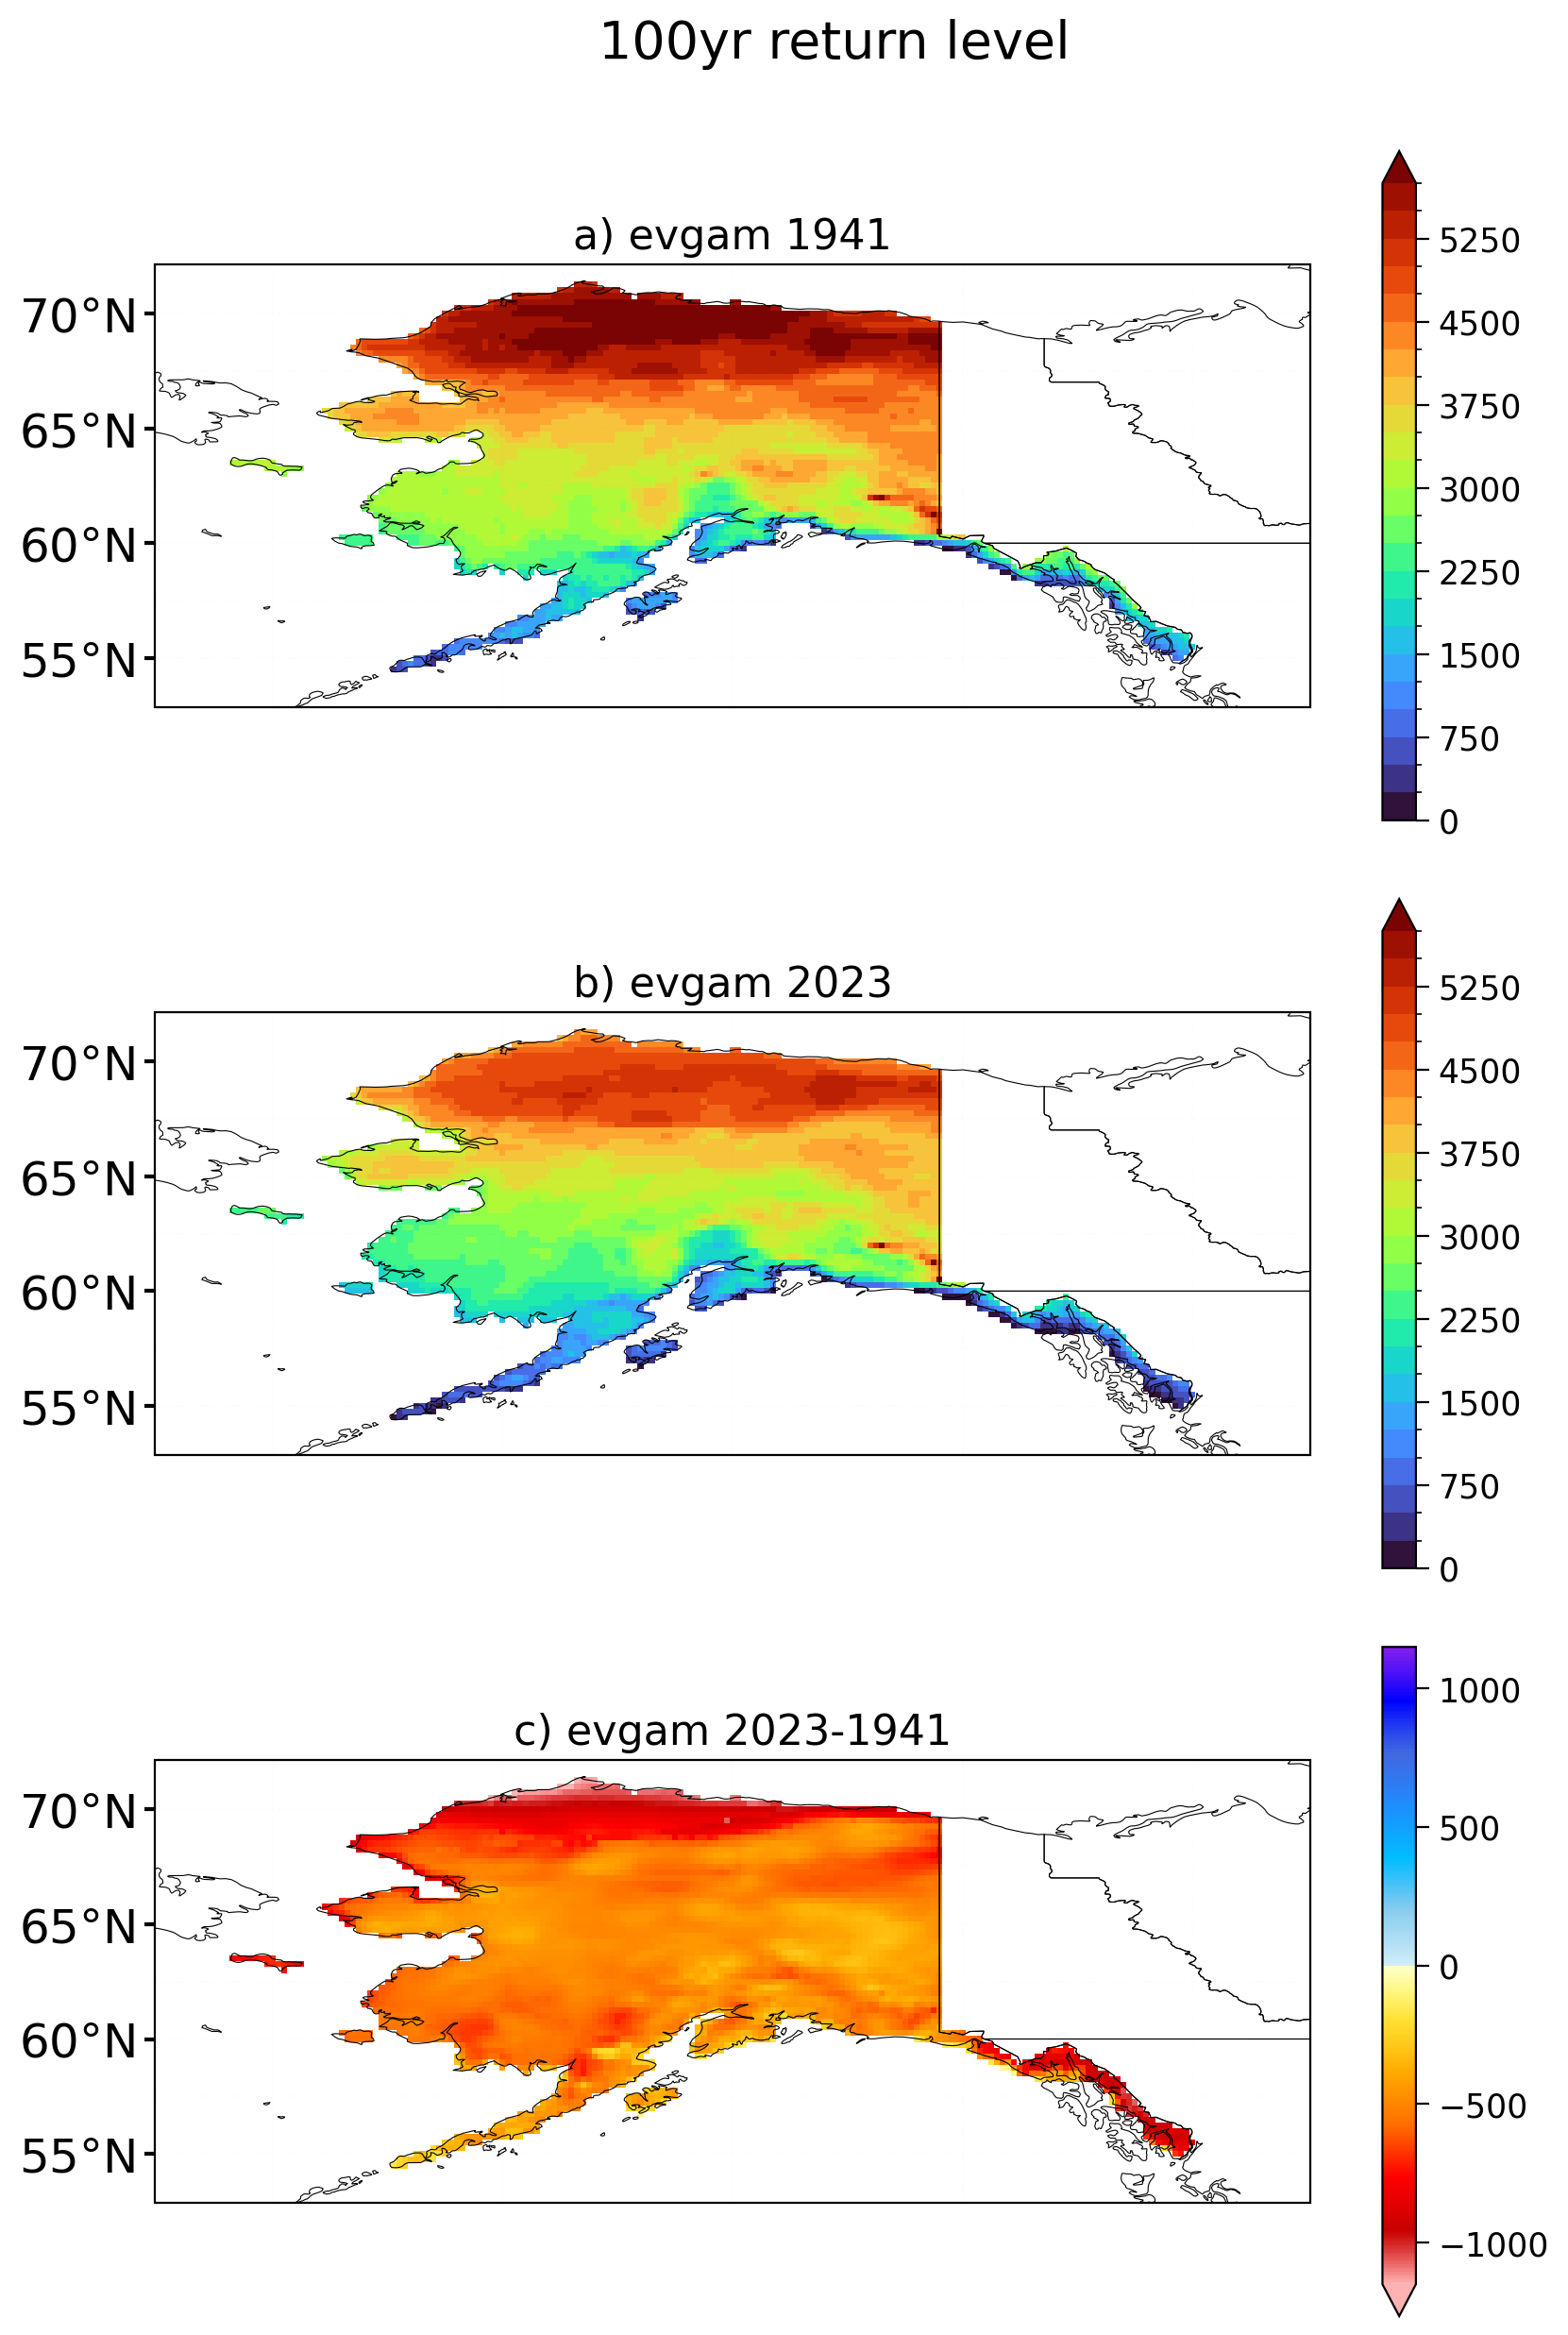

In [22]:
fig, ax = plt.subplots(nrows=3,ncols=1,figsize=(9,13),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.02,top=0.95, left=0.1,right=0.95,hspace=-0.05)
ax=ax.flatten()

shrink=0.85
#
#  Scale
#
clevs = np.arange(0,6000,250)

Rrl100.isel(time=0).plot(ax=ax[0],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[0].set_title(f'a) evgam {yearb}',fontsize=16)

Rrl100.isel(time=73).plot(ax=ax[1],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[1].set_title(f'b) evgam {yeare}',fontsize=16)

data=Rrl100.isel(time=73)-Rrl100.isel(time=0)
data=xr.where(Rrl100.isel(time=0)==spval,spval,data)
data.plot(ax=ax[2],cmap=cmapBR_rng,vmin=-1150,vmax=1150,cbar_kwargs={'label':'','shrink':shrink})
ax[2].set_title(f'c) evgam {yeare}-{yearb}',fontsize=16)
####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == 3: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('')  
fig.suptitle('100yr return level',fontsize=20)    
outfile=f'PLOTS/GEV_rl100_NS{itest}.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

In [34]:
print(f'Map of 100 year return-level ({units}) from the GEV analysis performed \n',
f'a) using the R-evgam package for the year {yearb},\n',
f'b) using the R-evgam package for the year {yeare},\n',
f'c) using the R-evgam package difference between the years {yeare} and {yearb}.\n',
f'In grey, not enough AFI values > 0.\n',
f'The black contours are showing the shape parameters contours [-0.5,0.5].')

Map of 100 year return-level (degree-days (°C)) from the GEV analysis performed 
 a) using the R-evgam package for the year 1941,
 b) using the R-evgam package for the year 2023,
 c) using the R-evgam package difference between the years 2023 and 1941.
 In grey, not enough AFI values > 0.
 The black contours are showing the shape parameters contours [-0.5,0.5].


# Bilotta - Like figure 4

<>:27: SyntaxWarning: invalid escape sequence '\d'
<>:29: SyntaxWarning: invalid escape sequence '\d'
<>:27: SyntaxWarning: invalid escape sequence '\d'
<>:29: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_56478/1425946108.py:27: SyntaxWarning: invalid escape sequence '\d'
  ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_56478/1425946108.py:29: SyntaxWarning: invalid escape sequence '\d'
  ax.set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax.get_xticks()],size=18)


min: dask.array<_nanmin_skip-aggregate, shape=(), dtype=float64, chunksize=(), chunktype=numpy.ndarray> max: dask.array<_nanmax_skip-aggregate, shape=(), dtype=float64, chunksize=(), chunktype=numpy.ndarray>


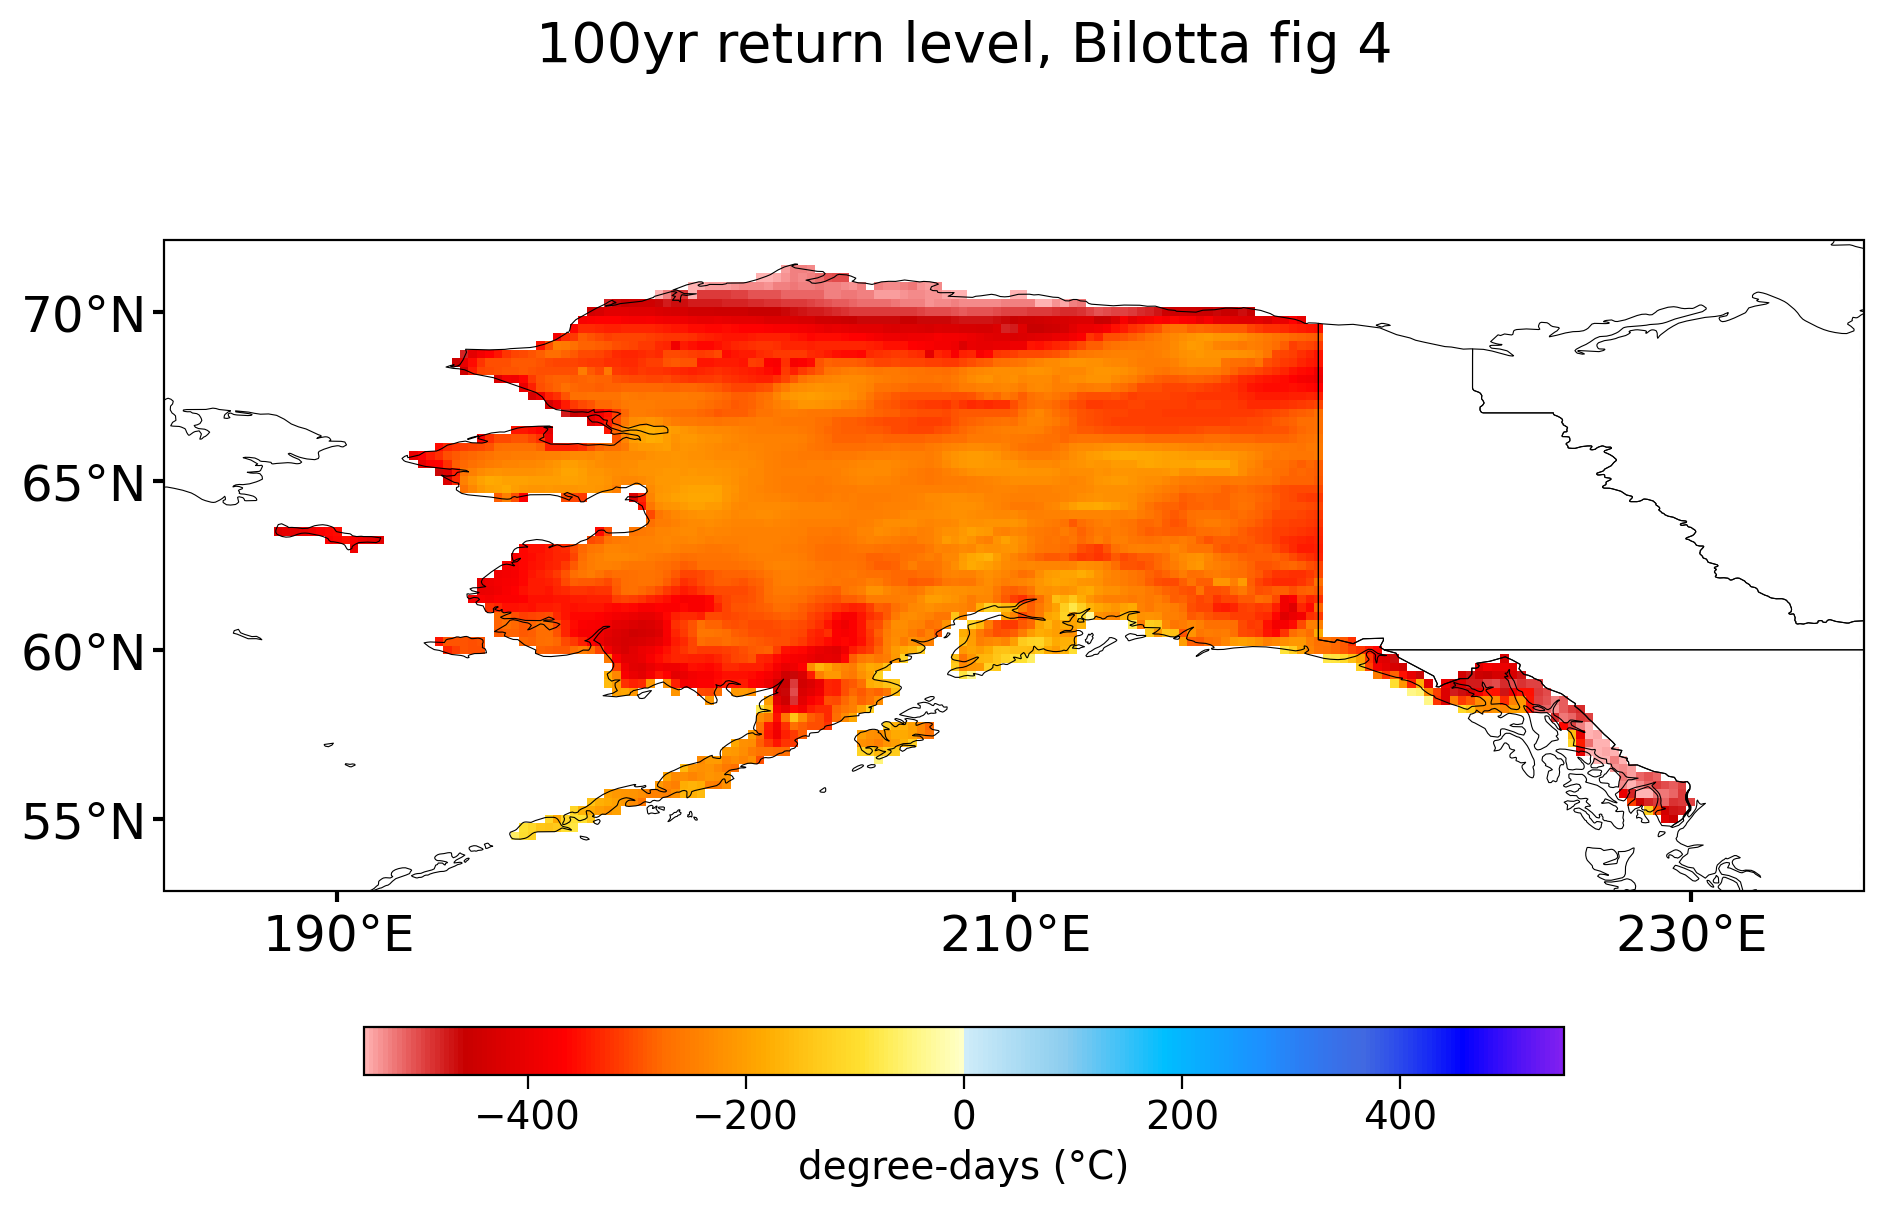

In [27]:
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,6),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15,top=0.9, left=0.1,right=0.95,hspace=-0.05)

shrink=0.65
#
#  Scale
#

data1081 = Rrl100.sel(time=slice(1981,2010)).mean('time')
data8051 = Rrl100.sel(time=slice(1951,1980)).mean('time')
data = data1081 - data8051
print('min:',data.min().data,'max:',data.max().data)
cc = data.plot(ax=ax,cmap=cmapBR_rng,vmin=-550,vmax=550,add_colorbar=False)

grd = ax.gridlines(crs=ccrs.PlateCarree(),
draw_labels=False, 
xlocs=np.arange(-125, -70,10),
ylocs=np.arange(30, 60,10),
color='gray', alpha=0.01, linestyle='--')

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')
ax.add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
ax.tick_params(axis='both',direction='out',width=1.5,length=4)
ax.set_yticks(ax.get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=18)
ax.set_xticks(ax.get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
ax.set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax.get_xticks()],size=18)
ax_cbar = fig.add_axes([0.2, 0.1, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,\
    shrink=0.8,location='bottom',orientation='horizontal')
cbar.set_label(label=f'{units}',fontsize=14)
cbar.ax.minorticks_off()
cbar.ax.tick_params(labelsize=14)
fig.suptitle('100yr return level, Bilotta fig 4',fontsize=20)    
outfile=f'PLOTS/GEV_figure4_NS{itest}.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

Differences in the 100-yr return periods calculated using the mean 1981–2010 data vs the mean 1951–80 data. 

# GRID POINTS ANALYSIS

In [28]:
ptlon=[210,211.]
ptlat=[ 60.25, 64.75  ]

<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:21: SyntaxWarning: invalid escape sequence '\d'
<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:21: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_56478/3206379547.py:18: SyntaxWarning: invalid escape sequence '\d'
  ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_56478/3206379547.py:21: SyntaxWarning: invalid escape sequence '\d'
  ax.set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax.get_xticks()],size=18)


Text(0.5, 1.0, '100yr return level,2023-1941')

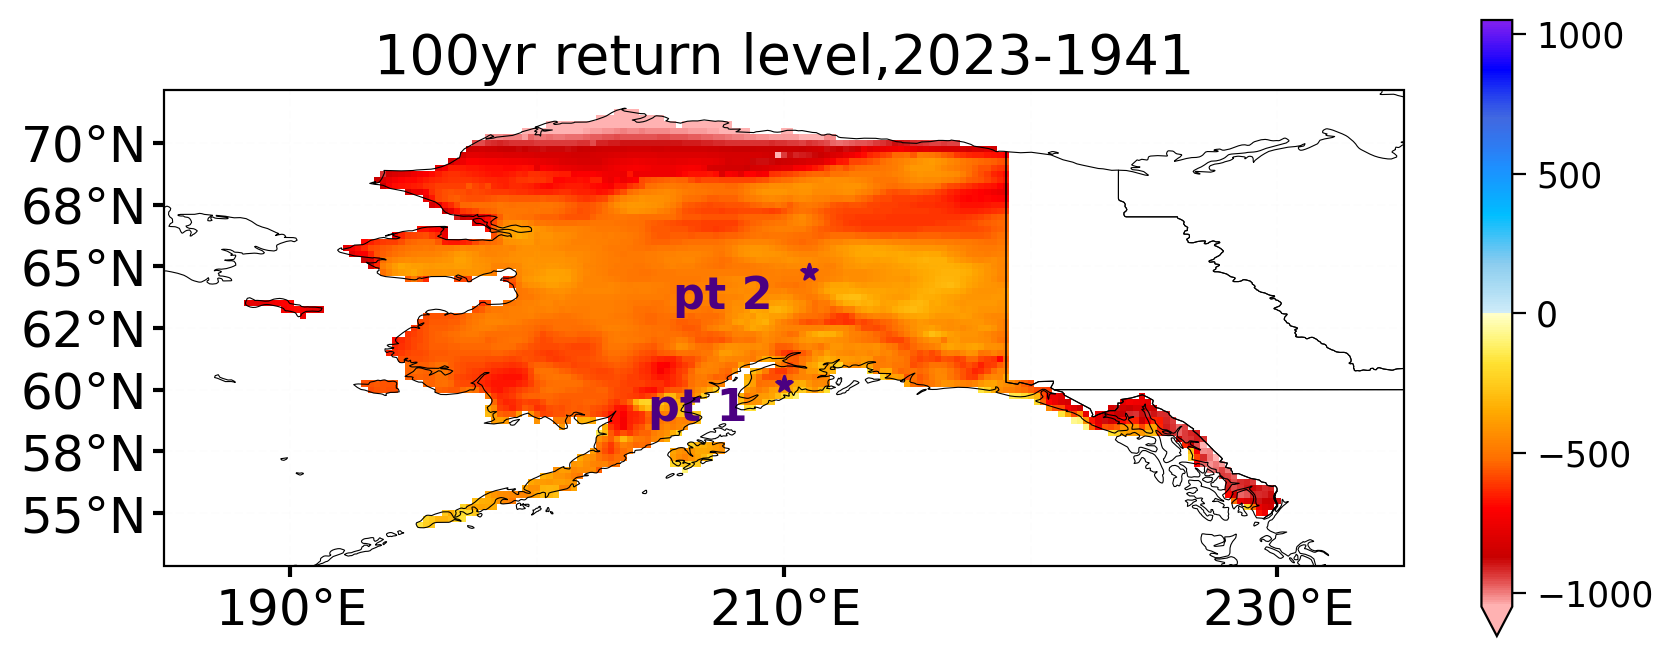

In [33]:
cmap=cmaps.BlGrYeOrReVi200

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,8),subplot_kw={'projection':proj})
data=Rrl100.isel(time=73)-Rrl100.isel(time=0)
data.plot(cmap=cmapBR_rng,vmin=-1050,vmax=1050,cbar_kwargs={'label':'','shrink':0.5})
for ip in range(0,len(ptlon)):
  ax.scatter(ptlon[ip],ptlat[ip],marker='*',color='indigo')
  ax.text(ptlon[ip]-360-5.5,ptlat[ip]-1.5,f'pt {ip+1}',color='indigo',size=16,weight='bold')

grd = ax.gridlines(
  draw_labels=False, 
  color='gray', alpha=0.01, linestyle='--')
ax.add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='both',direction='out',width=1.5,length=4)
ax.set_yticks(ax.get_yticks()[1:-1],crs=ccrs.PlateCarree())
ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=18)

ax.set_xticks(ax.get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
ax.set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax.get_xticks()],size=18)
ax.set_title(f'100yr return level,{yeare}-{yearb}',fontsize=20)

Differences in the 100-yr return periods between 2023 and 1950. The grey area marks where there is not enough AFI values >0 for the analysis. White area marks where the evgam code didn't give a result.

<>:51: SyntaxWarning: invalid escape sequence '\d'
<>:53: SyntaxWarning: invalid escape sequence '\d'
<>:53: SyntaxWarning: invalid escape sequence '\d'
<>:69: SyntaxWarning: invalid escape sequence '\d'
<>:69: SyntaxWarning: invalid escape sequence '\d'
<>:79: SyntaxWarning: invalid escape sequence '\d'
<>:84: SyntaxWarning: invalid escape sequence '\d'
<>:84: SyntaxWarning: invalid escape sequence '\d'
<>:94: SyntaxWarning: invalid escape sequence '\d'
<>:99: SyntaxWarning: invalid escape sequence '\d'
<>:99: SyntaxWarning: invalid escape sequence '\d'
<>:109: SyntaxWarning: invalid escape sequence '\d'
<>:114: SyntaxWarning: invalid escape sequence '\d'
<>:114: SyntaxWarning: invalid escape sequence '\d'
<>:51: SyntaxWarning: invalid escape sequence '\d'
<>:53: SyntaxWarning: invalid escape sequence '\d'
<>:53: SyntaxWarning: invalid escape sequence '\d'
<>:69: SyntaxWarning: invalid escape sequence '\d'
<>:69: SyntaxWarning: invalid escape sequence '\d'
<>:79: SyntaxWarning: invali

#############
#############
Point 1
#############
#############


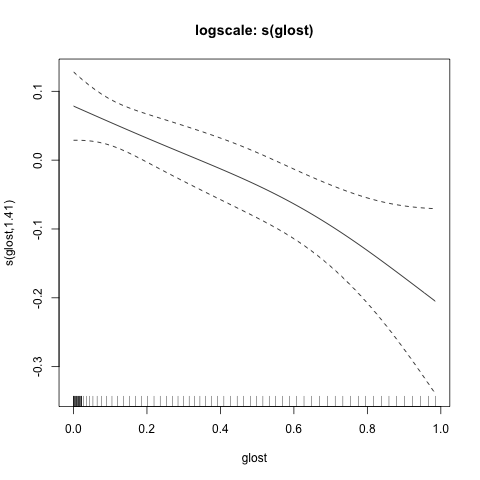


** Parametric terms **

logscale
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     7.36       0.02   312.2   <2e-16

logshape
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     1.59       0.09   18.21   <2e-16

** Smooth terms **

logscale
          edf max.df Chi.sq Pr(>|t|)
s(glost) 1.41      4   12.5 0.000964
#############
#############
Point 2
#############
#############


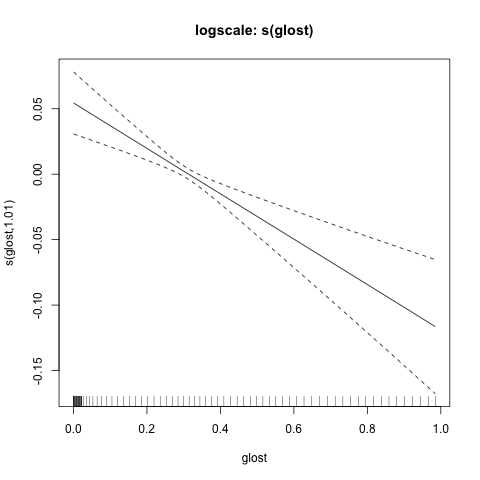


** Parametric terms **

logscale
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     7.99       0.01  639.86   <2e-16

logshape
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     2.23       0.09   25.72   <2e-16

** Smooth terms **

logscale
          edf max.df Chi.sq Pr(>|t|)
s(glost) 1.01      4  21.14 4.53e-06


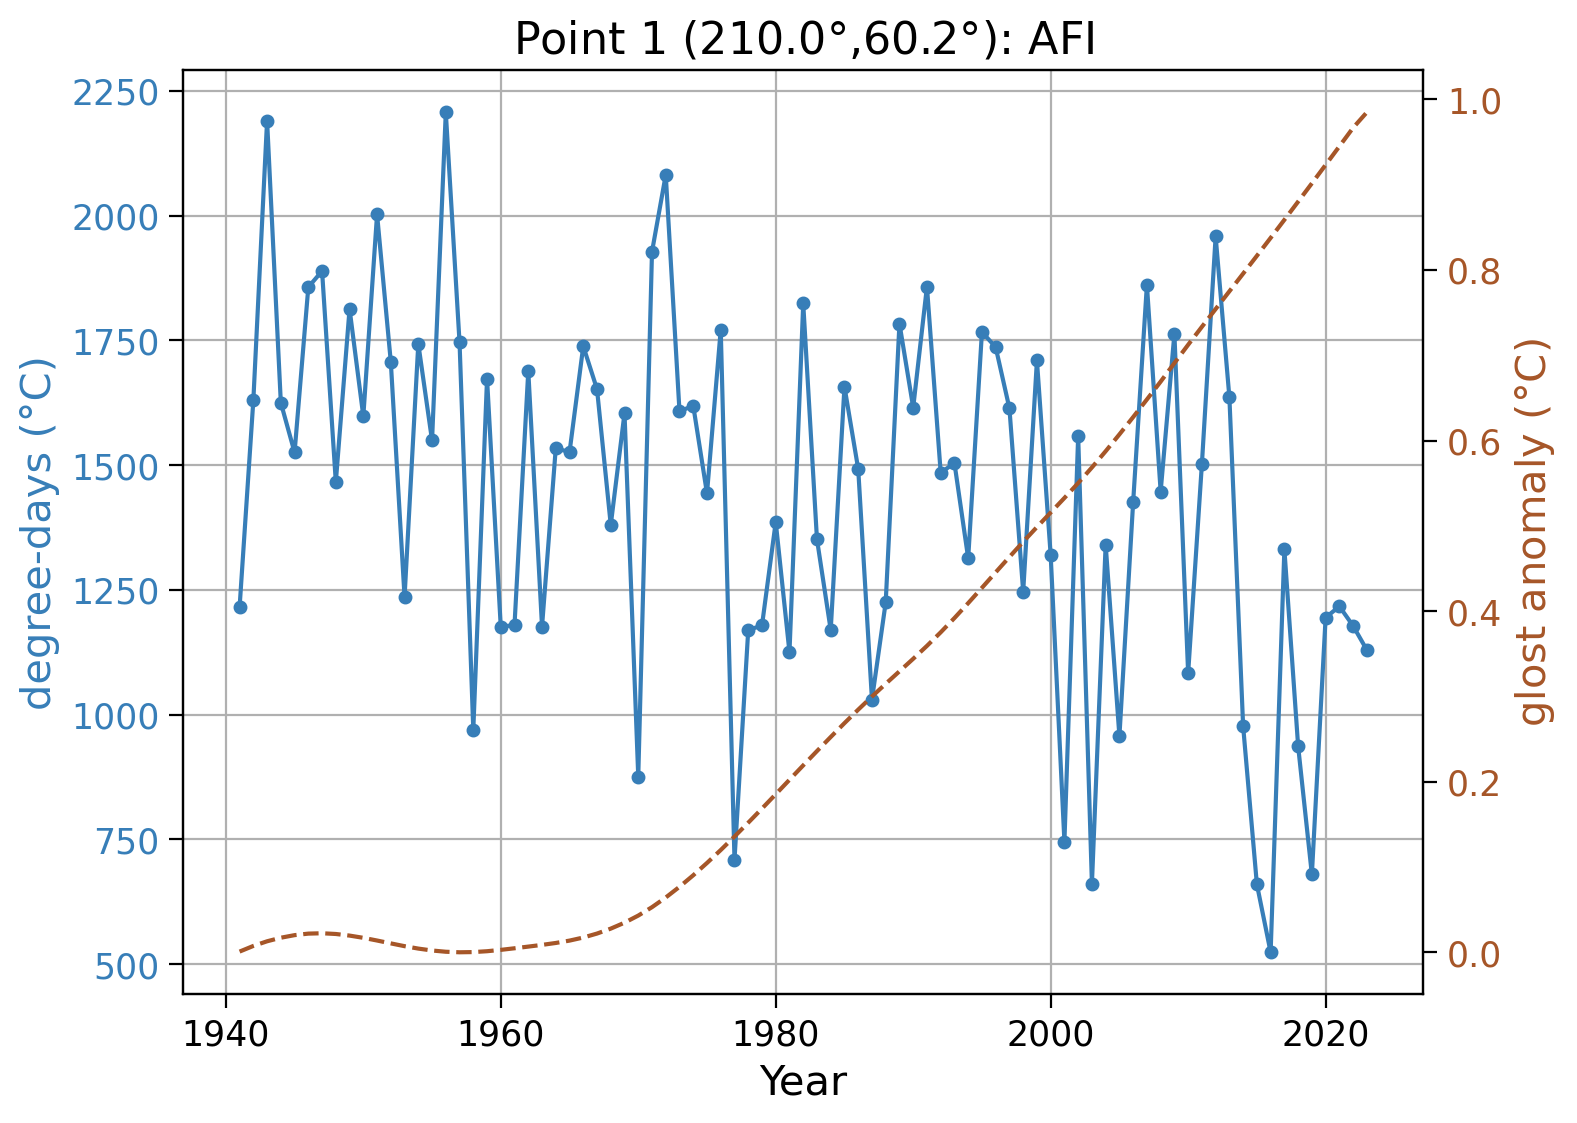

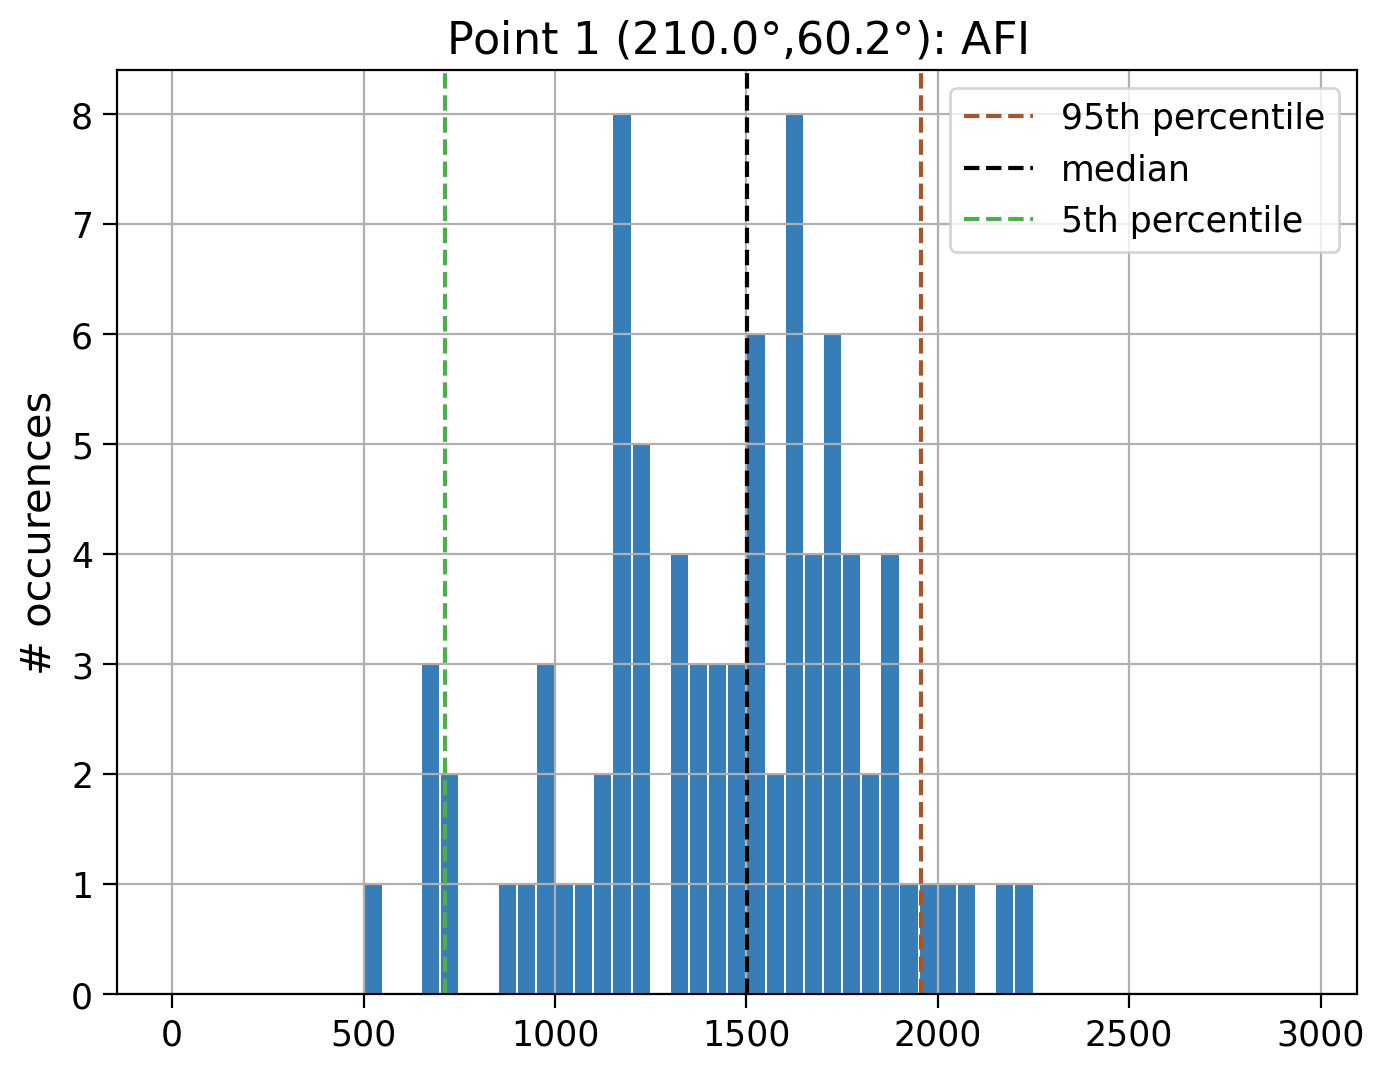

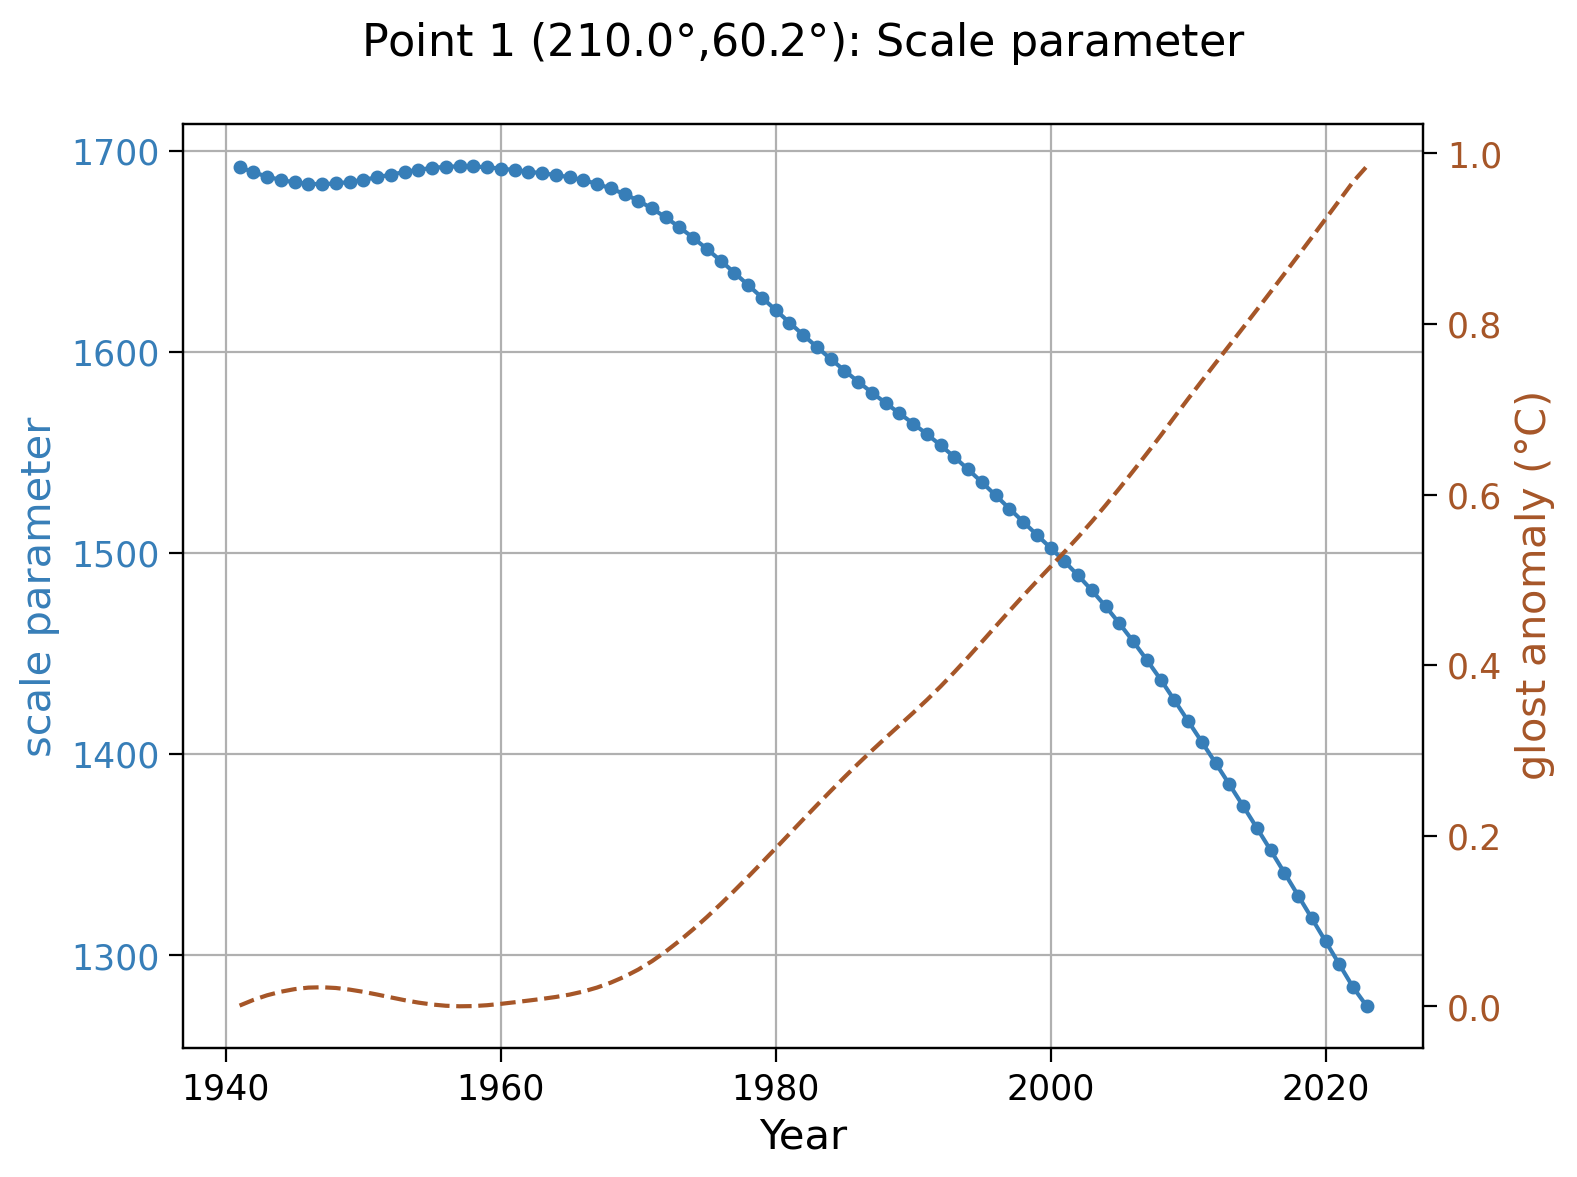

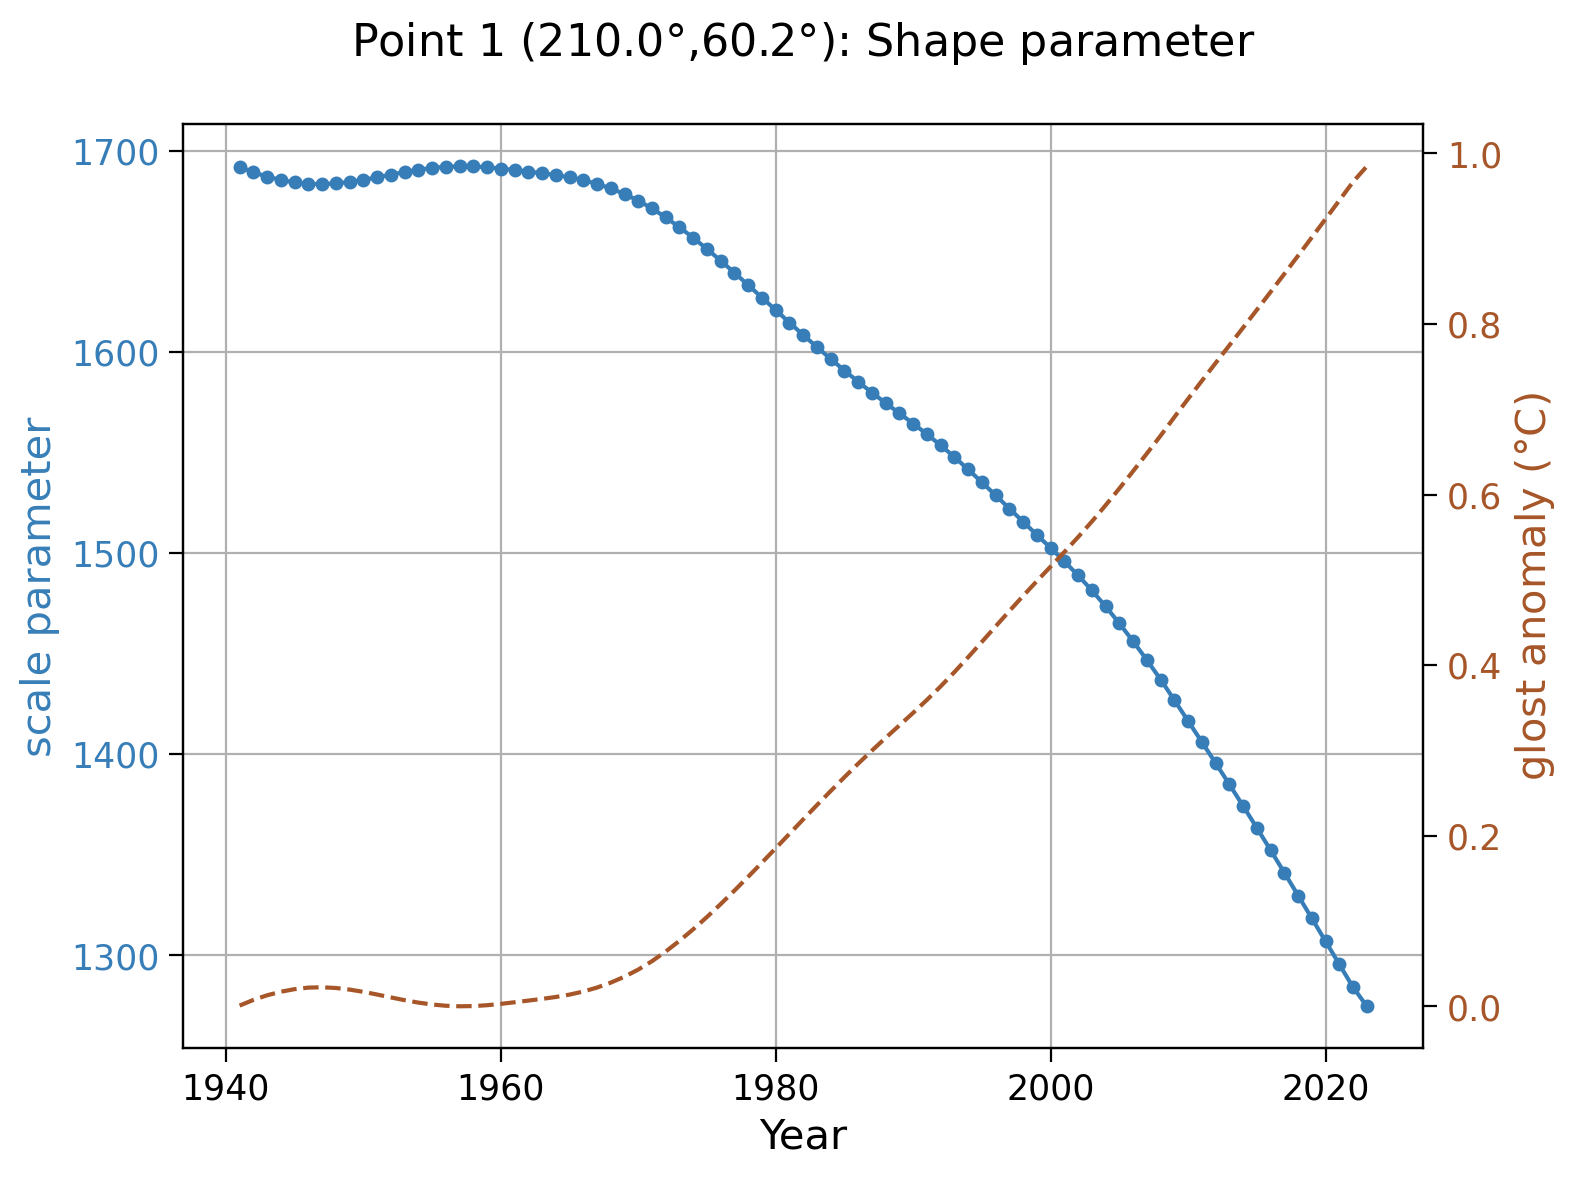

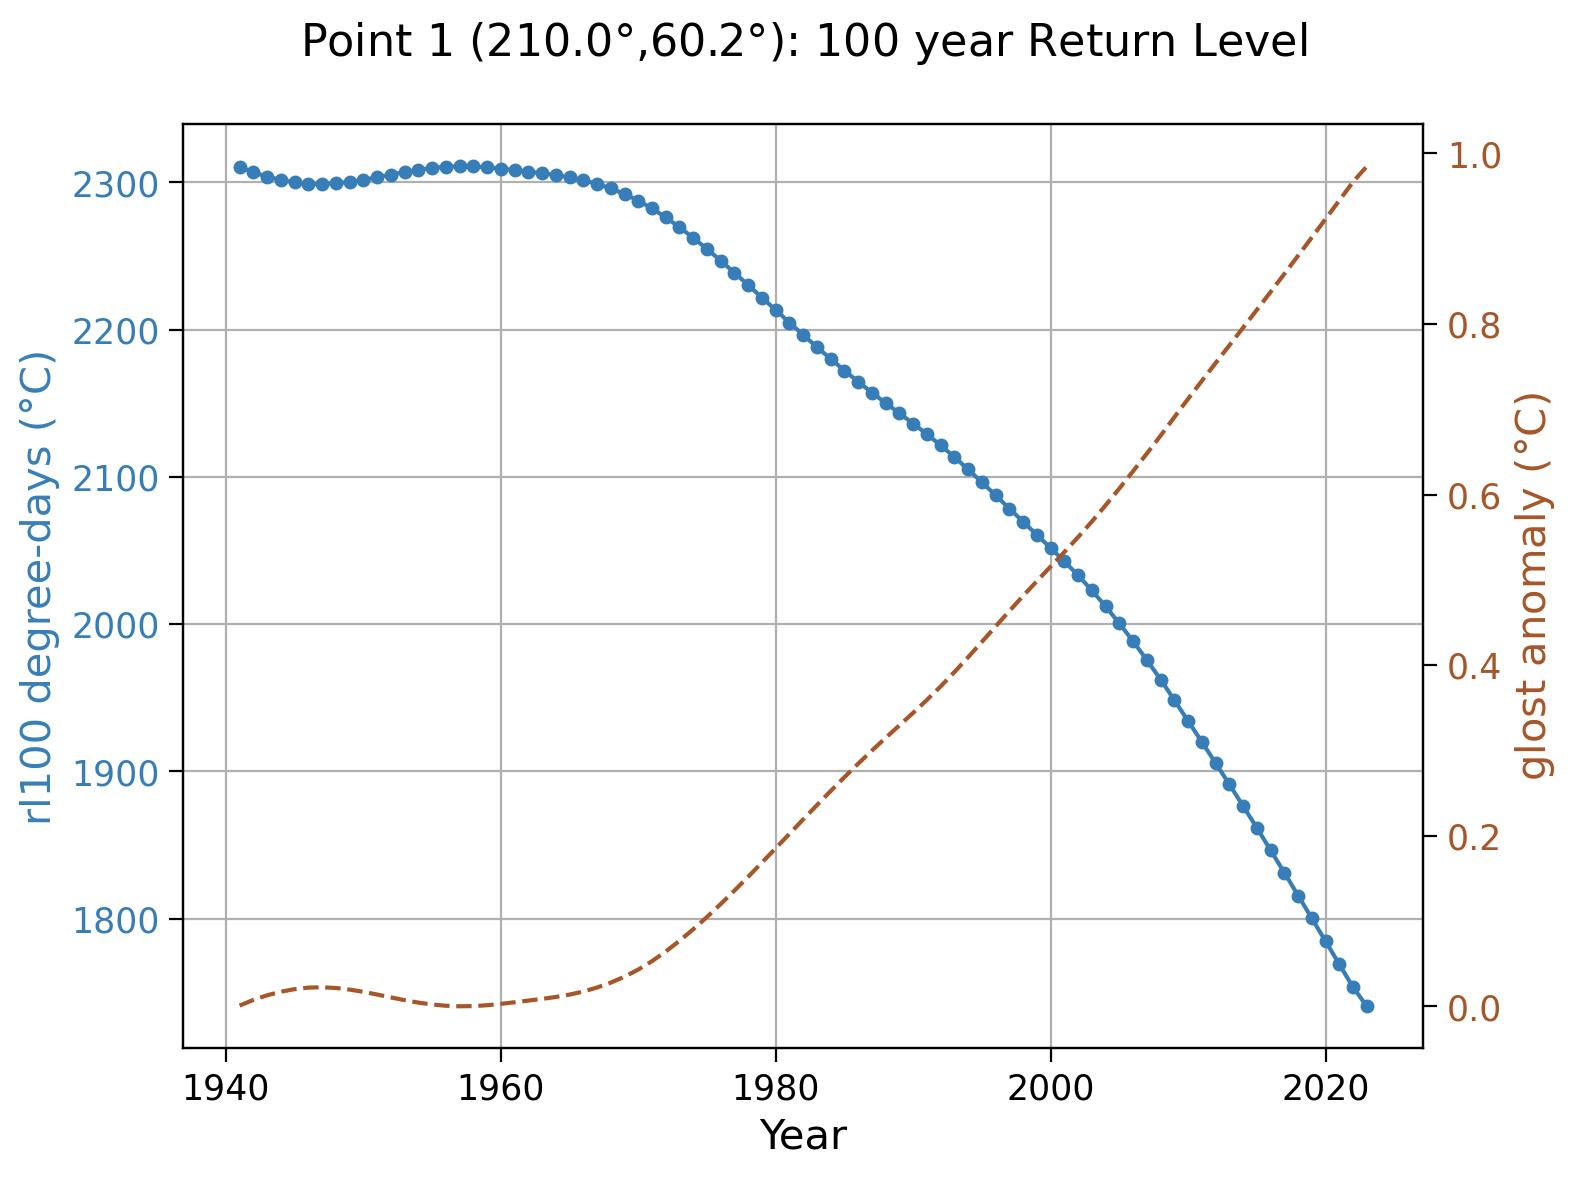

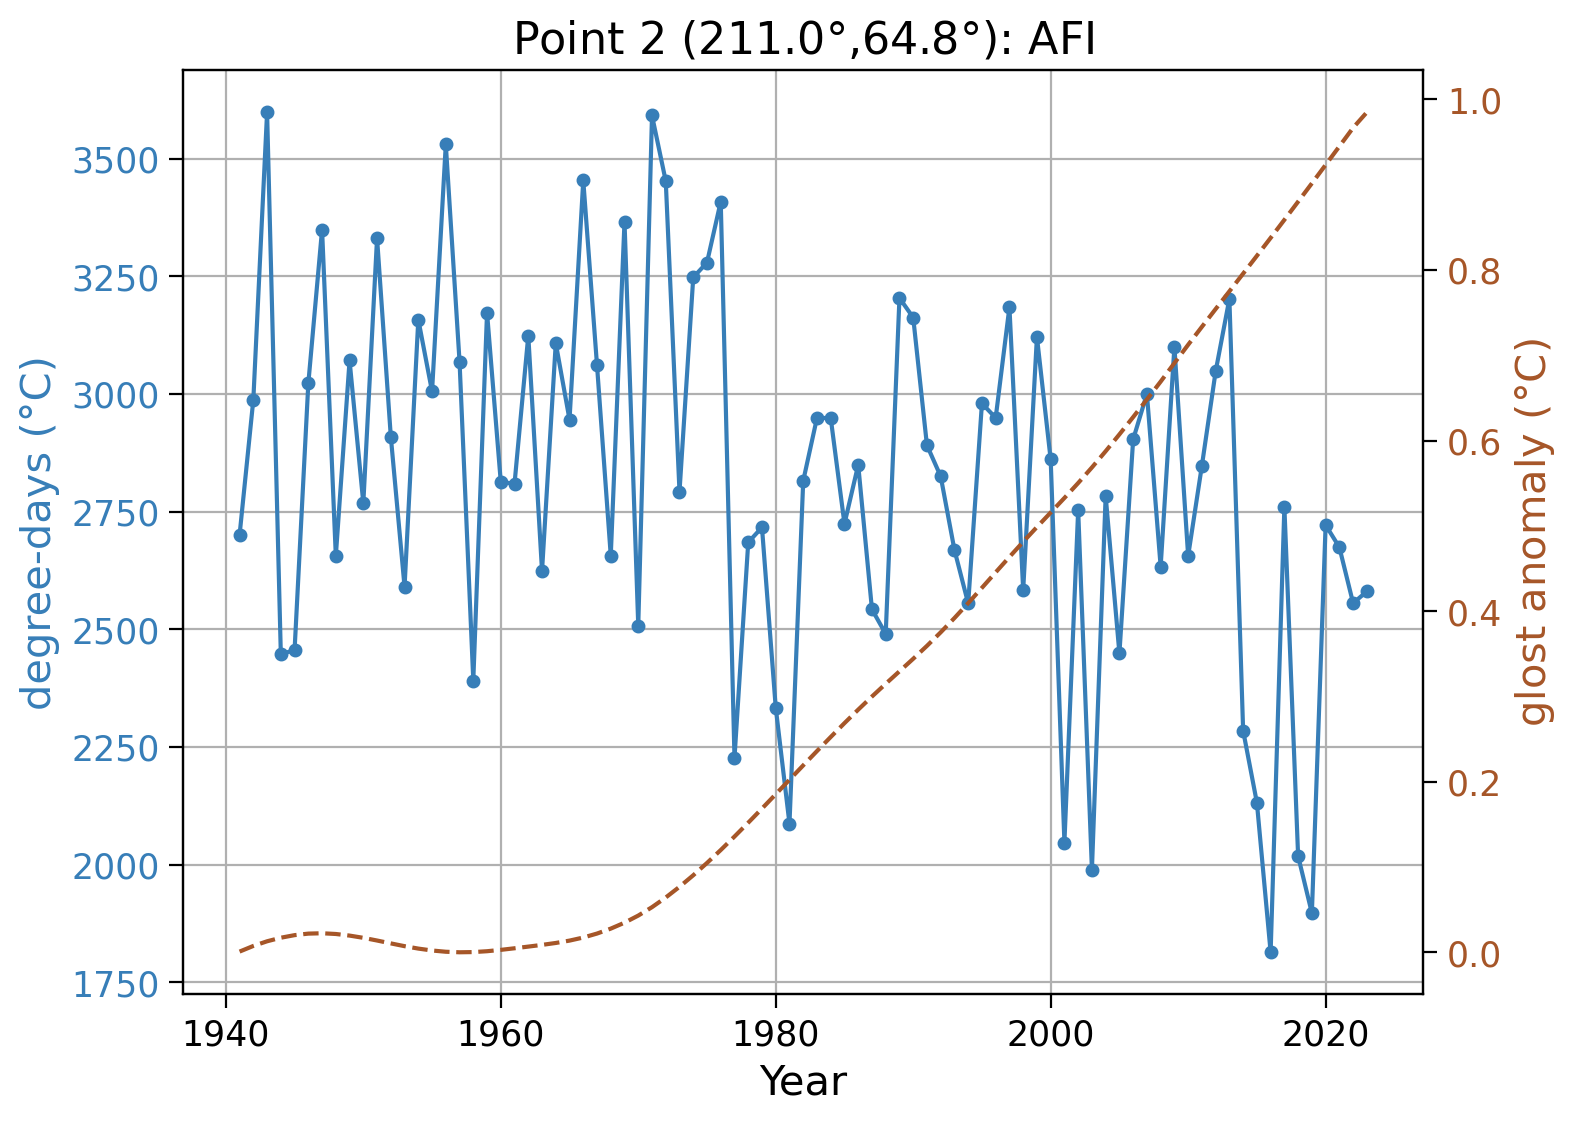

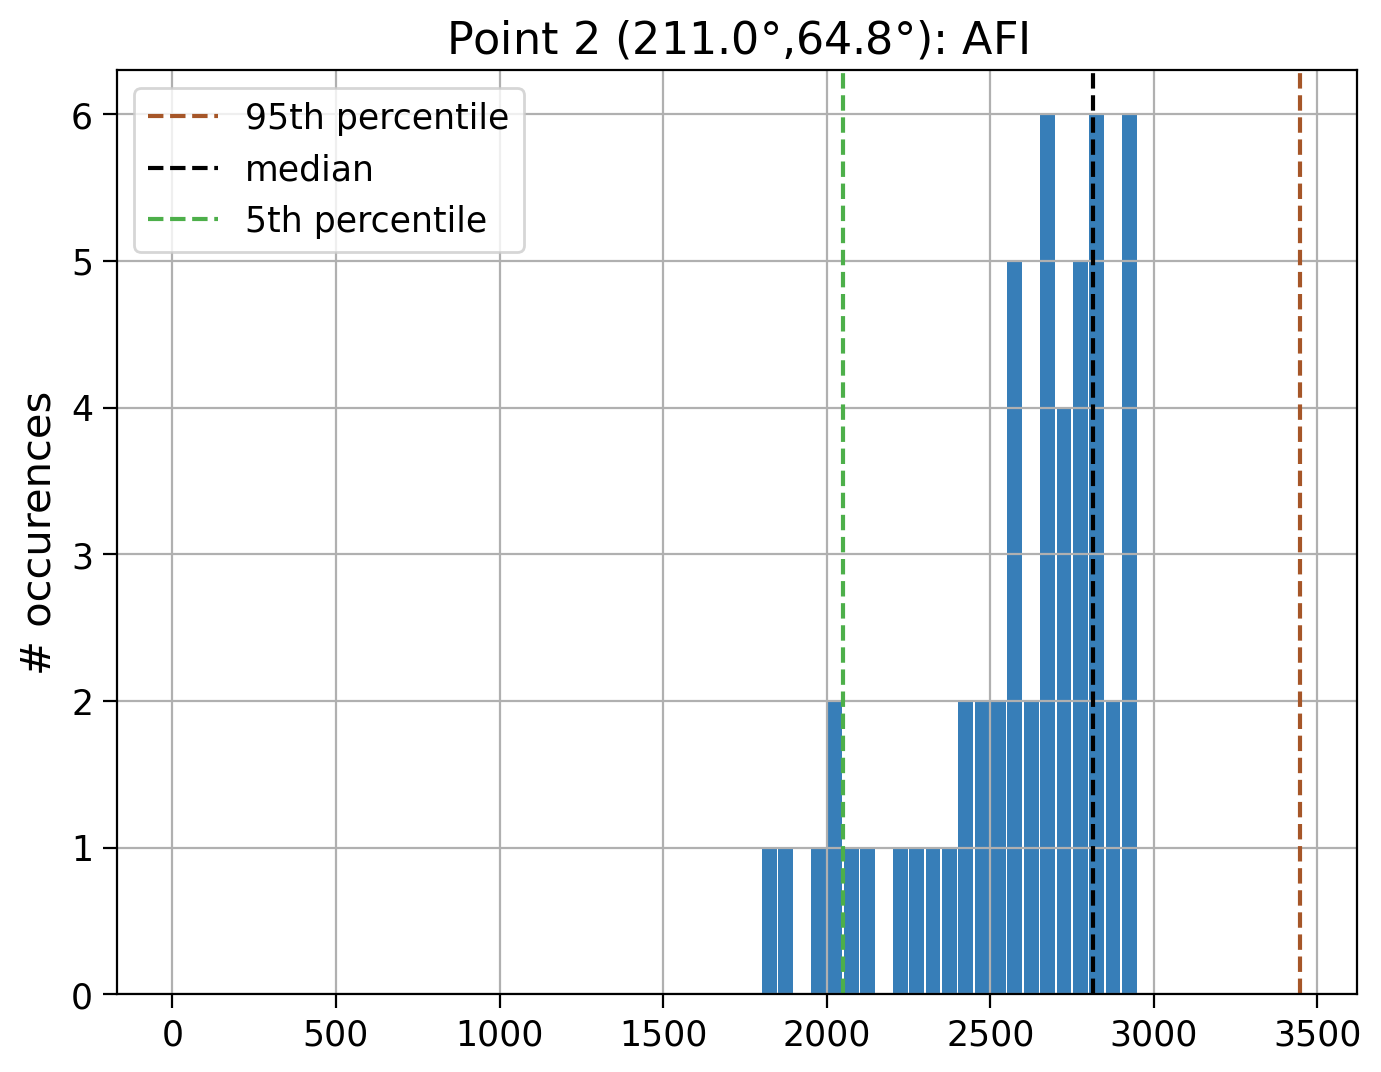

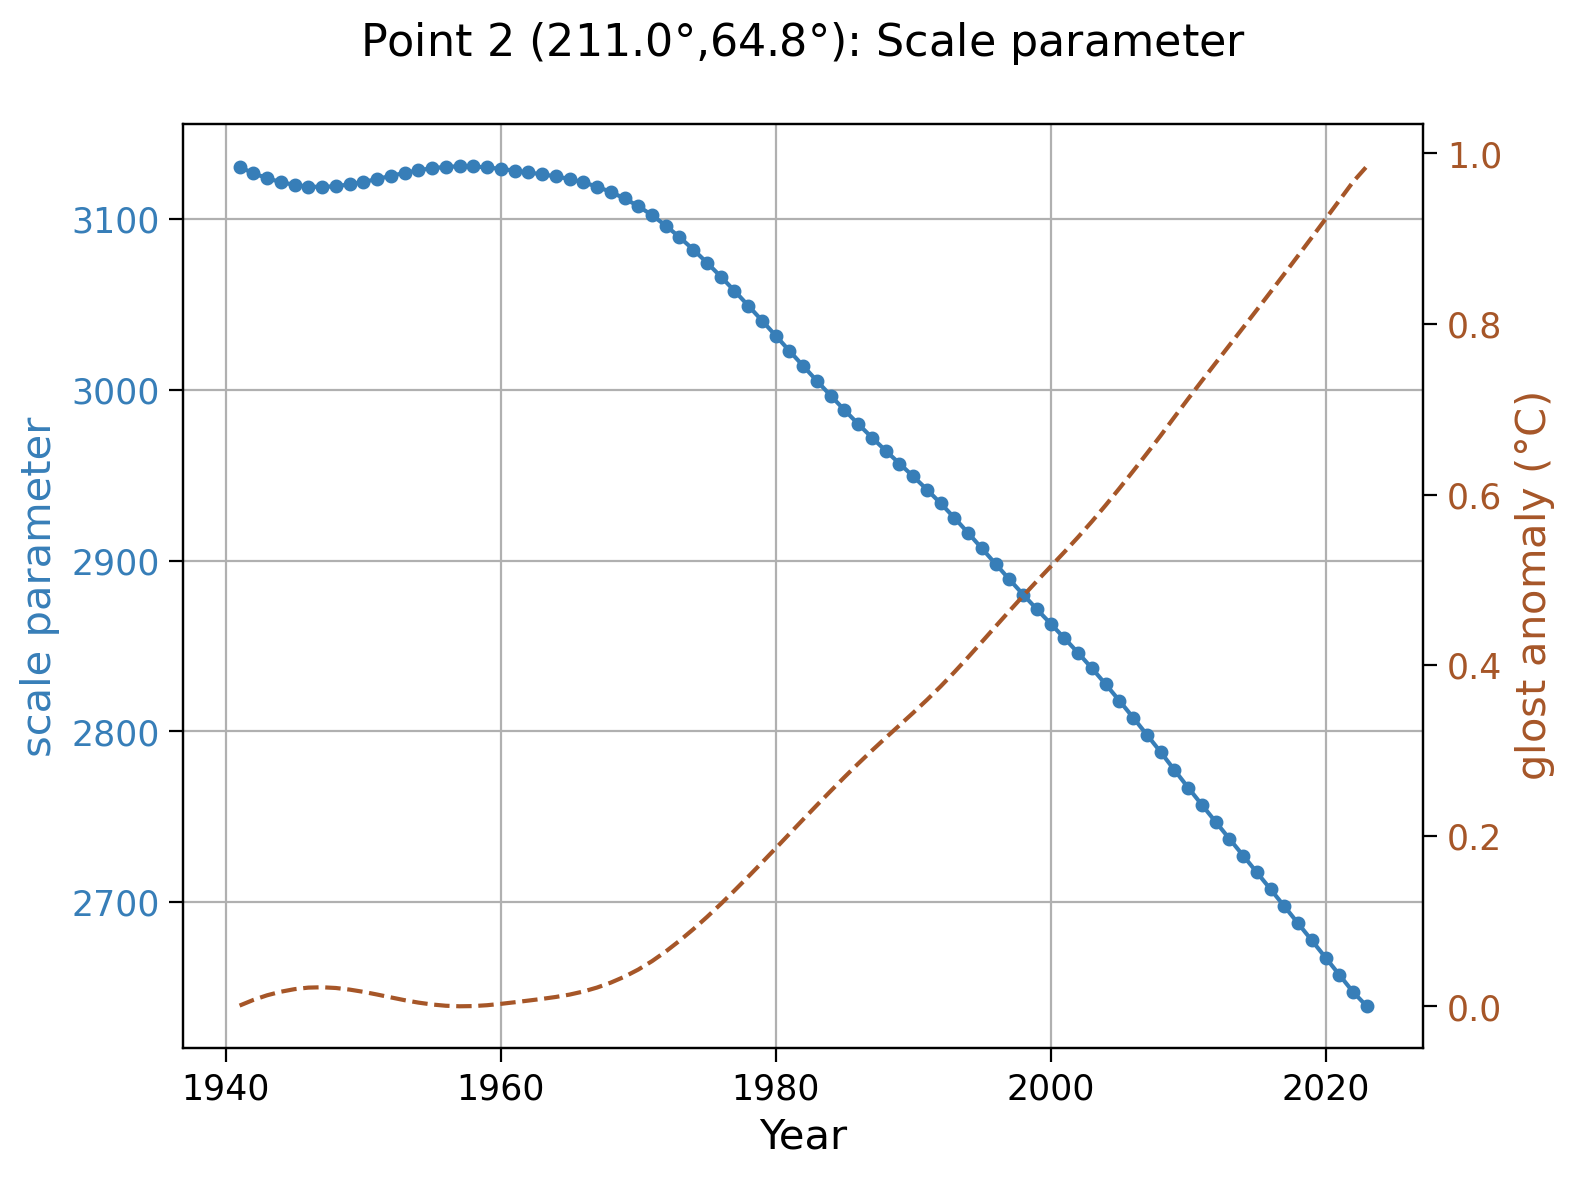

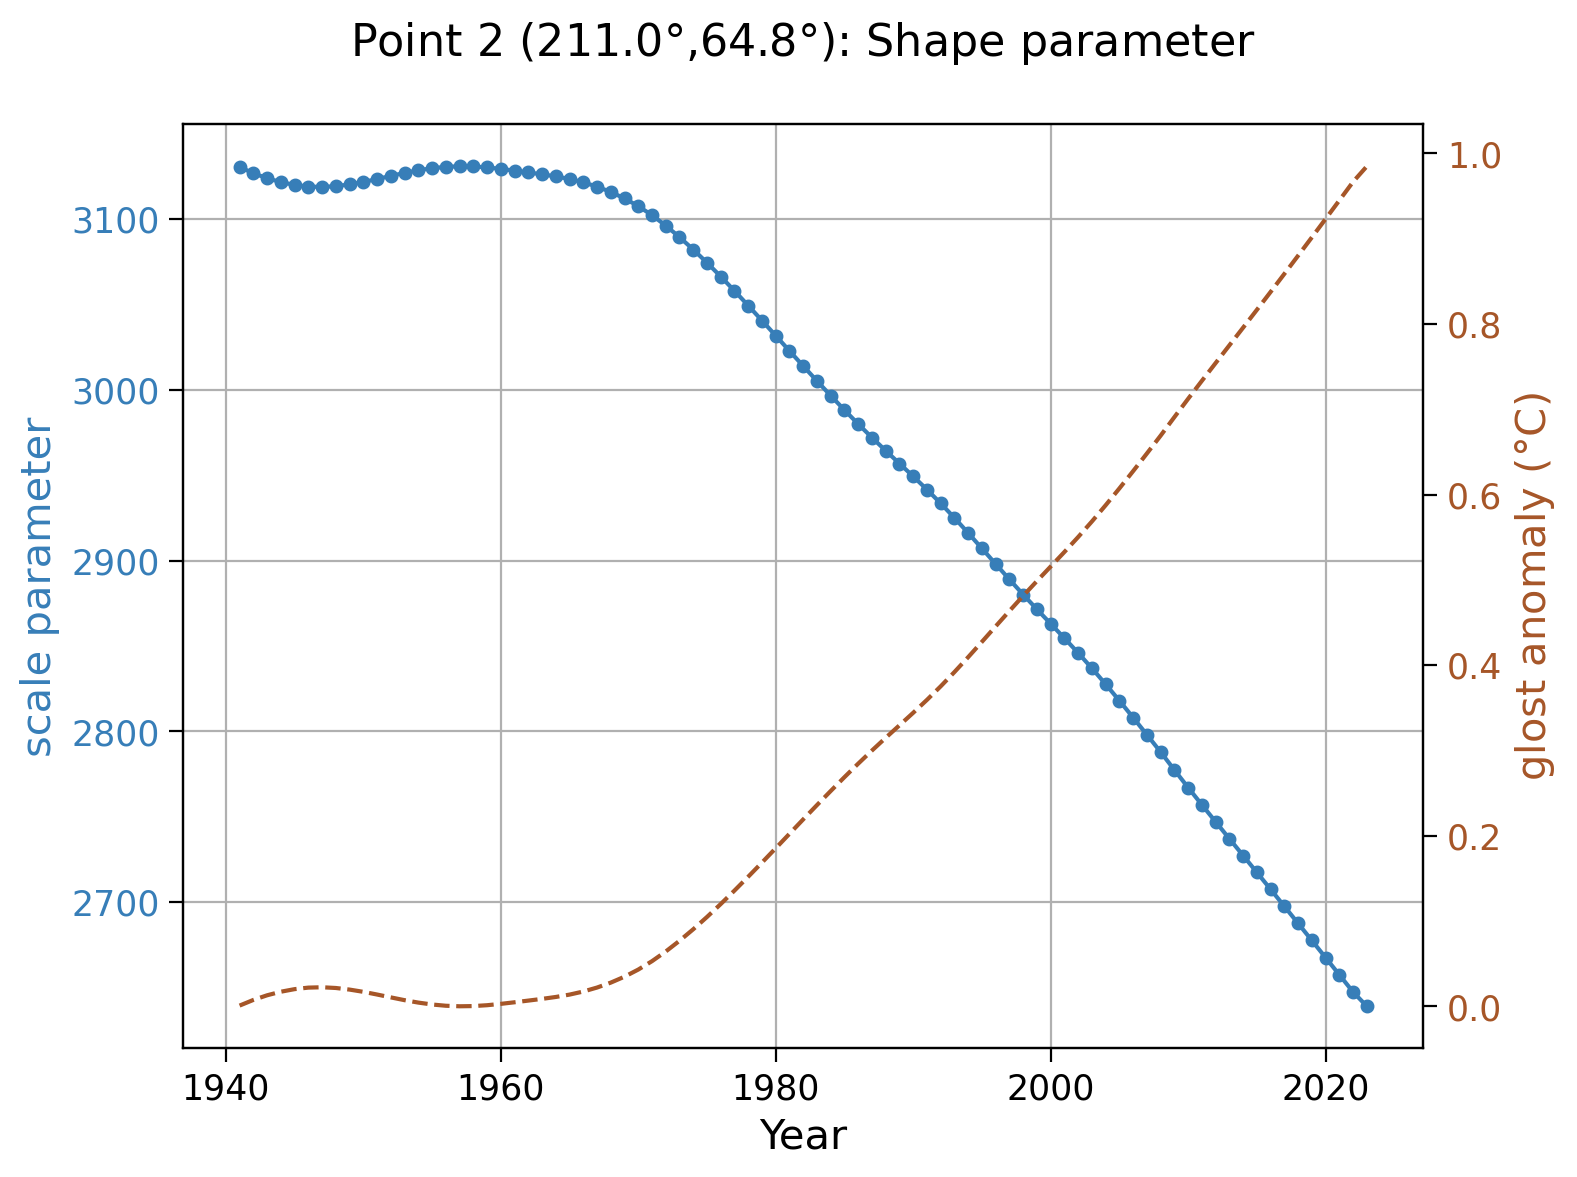

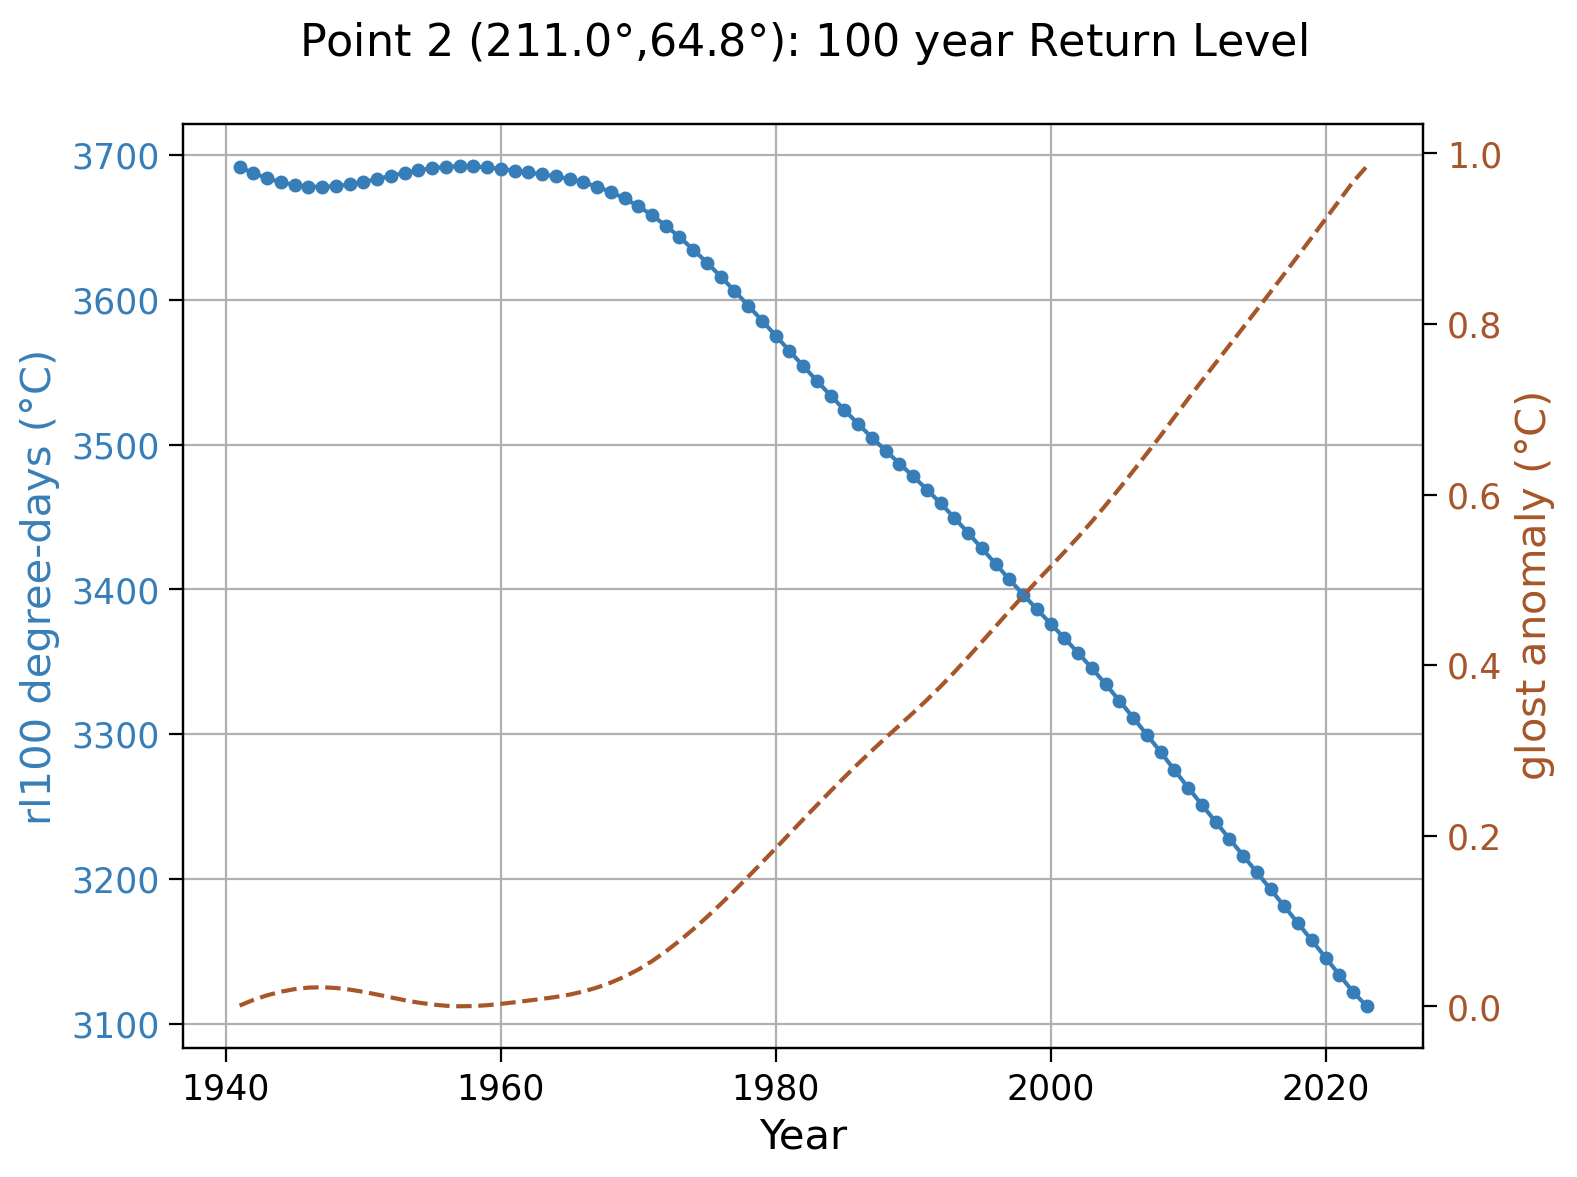

In [34]:
bins=np.arange(0,3000,50)

for ij in range(0,len(ptlon)):
  ilon=ptlon[ij]
  ilat=ptlat[ij]
  # Extract values for boxes
  dsij=dsa.sel(lon=ilon,lat=ilat).load()
  df = dsij.to_dataframe()
  df = df.reset_index()
  # Remove zeros and NAN 
  # Remove timeseries with less than 15 data (as in Bilotta et al.)
  # Save rows removed
  dfsave=df[(df['AFI'] <= 0.)|(df['AFI'].isna())]
  df = df[df['AFI'] > 0.]

  dfsave=pd.concat([dfsave, df.groupby(['lon', 'lat']).filter(lambda x: len(x) <= 49)])
  df=df.groupby(['lon', 'lat']).filter(lambda x: len(x) > 49)
  # Convert xarray to pandas DataFrame to R data.frame
  # You can now work with 'r_df' in R

  with (ro.default_converter + pandas2ri.converter).context():
    r_df = ro.conversion.get_conversion().py2rpy(df)
  globalenv['r_df'] = r_df

  # EVGAM model fitting  
  %R m_gev <- evgam(fmla_gev, r_df, family = "weibull")
  %R gev_pred <- predict(m_gev, r_df, type = "response", family = "weibull")
  %R gev_rl100 <- predict(m_gev, r_df, prob = 0.99, family = "weibull")
  print('#############')
  print('#############')
  print(f'Point {ij+1}')
  print('#############')
  print('#############')

  %R plot(m_gev)
  %R pp<-summary(m_gev)
  %R scale_pvalue <- pp[[2]][['logscale']][['Pr(>|t|)']]
  %R print(pp)
  %R -o gev_pred,pp,gev_rl100,scale_pvalue
  #####
  # PLOTS
  #####
  fig, ax1 = plt.subplots()
  ax2 = ax1.twinx()
  ax1.plot(np.arange(yearb,yeare+1,1),dsij['AFI'],color='#377eb8',marker='o',markersize=4)
  ax1.set_ylabel(f'{units}', color='#377eb8')
  ax1.tick_params(axis='y', labelcolor='#377eb8')
  ax1.set_xlabel('Year')
  ax1.grid()
  ax2.plot(np.arange(yearb,yeare+1,1),ann_glost,linestyle='--',color='#a65628',label='glost anomaly')
  ax2.set_ylabel('glost anomaly ($\degree$C)', color='#a65628')
  ax2.tick_params(axis='y', labelcolor='#a65628')
  ax1.set_title(f'Point {ij+1} ({ilon:0.1f}$\degree$,{ilat:0.1f}$\degree$): AFI',fontsize=16)
  outfile=f'PLOTS/AFI_glost_timeseries_NS{itest}_pt{ij+1}.png'
  plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')
  ######
  d1=histogram(dsij['AFI'], bins=bins, block_size=None)
  per90th=dsij['AFI'].quantile(0.95)
  per50th=dsij['AFI'].quantile(0.5)
  per10th=dsij['AFI'].quantile(0.05)
  fig, axs = plt.subplots()
  axs.bar((bins[1:]+bins[:-1])*0.5,d1.data,color='#377eb8',width=45)
  axs.axvline(per90th,color='#a65628', linewidth=1.5,linestyle='--', label="95th percentile" )
  axs.axvline(per50th,color='black',linewidth=1.5,linestyle='--', label="median")
  axs.axvline(per10th,color='#4daf4a',  linewidth=1.5,linestyle='--', label="5th percentile" )
  axs.set_ylabel('# occurences', color='k')
  axs.grid()
  plt.legend(loc='best')
  axs.set_title(f'Point {ij+1} ({ilon:0.1f}$\degree$,{ilat:0.1f}$\degree$): AFI',fontsize=16)
  outfile=f'PLOTS/AFI_glost_histogram_NS{itest}_pt{ij+1}.png'
  plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')
  ######
  fig, ax1 = plt.subplots()
  ax2 = ax1.twinx()
  ax1.plot(np.arange(yearb,yeare+1,1),gev_pred['scale'],color='#377eb8',marker='o',markersize=4)
  ax1.set_ylabel(f'scale parameter', color='#377eb8')
  ax1.tick_params(axis='y', labelcolor='#377eb8')
  ax2.plot(np.arange(yearb,yeare+1,1),ann_glost,linestyle='--',color='#a65628',label='glost anomaly')
  ax2.set_ylabel('glost anomaly ($\degree$C)', color='#a65628')
  ax2.tick_params(axis='y', labelcolor='#a65628')
  ax1.set_xlabel('Year')
  ax1.grid()
  ax1.set_title(f'Point {ij+1} ({ilon:0.1f}$\degree$,{ilat:0.1f}$\degree$): Scale parameter\n\
    ',fontsize=16)
  outfile=f'PLOTS/scale_glost_timeseries_NS{itest}_pt{ij+1}.png'
  plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')
    ######
  fig, ax1 = plt.subplots()
  ax2 = ax1.twinx()
  ax1.plot(np.arange(yearb,yeare+1,1),gev_pred['scale'],color='#377eb8',marker='o',markersize=4)
  ax1.set_ylabel(f'scale parameter', color='#377eb8')
  ax1.tick_params(axis='y', labelcolor='#377eb8')
  ax2.plot(np.arange(yearb,yeare+1,1),ann_glost,linestyle='--',color='#a65628',label='glost anomaly')
  ax2.set_ylabel('glost anomaly ($\degree$C)', color='#a65628')
  ax2.tick_params(axis='y', labelcolor='#a65628')
  ax1.set_xlabel('Year')
  ax1.grid()
  ax1.set_title(f'Point {ij+1} ({ilon:0.1f}$\degree$,{ilat:0.1f}$\degree$): Shape parameter\n\
   ',fontsize=16)
  outfile=f'PLOTS/shape_glost_timeseries_NS{itest}_pt{ij+1}.png'
  plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')
  ######
  fig, ax1 = plt.subplots()
  ax2 = ax1.twinx()
  ax1.plot(np.arange(yearb,yeare+1,1),gev_rl100['q:0.99'],color='#377eb8',marker='o',markersize=4)
  ax1.set_ylabel(f'rl100 {units}', color='#377eb8')
  ax1.tick_params(axis='y', labelcolor='#377eb8')
  ax2.plot(np.arange(yearb,yeare+1,1),ann_glost,linestyle='--',color='#a65628',label='glost anomaly')
  ax2.set_ylabel('glost anomaly ($\degree$C)', color='#a65628')
  ax2.tick_params(axis='y', labelcolor='#a65628')
  ax1.set_xlabel('Year')
  ax1.grid()
  ax1.set_title(f'Point {ij+1} ({ilon:0.1f}$\degree$,{ilat:0.1f}$\degree$): 100 year Return Level\n\
    ',fontsize=16)
  outfile=f'PLOTS/rl100_glost_timeseries_NS{itest}_pt{ij+1}.png'
  plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')